# Statistics and Regression Analysis using Python
## Week 1 — AI/ML Training Program Mini Project

**Dataset:** California Housing Dataset  
**Source:** Scikit-learn (`fetch_california_housing`)  
**Tools:** Python, Jupyter Notebook, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn  

---

### Project Objective

The objective of this project is to apply fundamental statistical concepts and regression techniques to the California Housing dataset. The analysis follows a structured data science workflow, including data inspection, data cleaning, descriptive statistics, exploratory data analysis (EDA), correlation analysis, data visualization, Simple Linear Regression, and Multiple Linear Regression.

The project focuses on interpreting statistical results and understanding how data characteristics influence predictive modeling. The performance of regression models is evaluated using R² Score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

As an extension, advanced machine learning and interpretability techniques are explored to compare predictive performance and understand feature contributions.

# Part 1 — Data Import & Inspection

## 1.1 Import Required Libraries

In this section, the necessary Python libraries are imported for data manipulation, numerical analysis, visualization, and machine learning.

In [2]:
# Data manipulation and numerical computing
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_california_housing

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1.2 Load the California Housing Dataset

The California Housing dataset is loaded directly from Scikit-learn using `fetch_california_housing()`. The dataset contains information collected from California census block groups, with several numerical features describing housing and demographic characteristics.

The target variable, `MedHouseVal`, represents the median house value for each block group, expressed in units of $100,000.

In [3]:
# Load the California Housing dataset as a pandas DataFrame
housing = fetch_california_housing(as_frame=True)

# Create the complete DataFrame containing features and target
df = housing.frame

print("California Housing dataset loaded successfully.")

California Housing dataset loaded successfully.


In [4]:
# Display the dimensions of the loaded dataset
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 20640
Number of columns: 9


In [5]:
from pathlib import Path

# Create the data directory if it does not already exist
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

# Save the dataset used in this project
df.to_csv(data_dir / "california_housing.csv", index=False)

print("Dataset saved to: data/california_housing.csv")

Dataset saved to: data/california_housing.csv


## 1.3 Preview the Dataset

To understand the structure and format of the data, the first 10 rows and the last 5 rows of the dataset are displayed below.

In [6]:
# Display the first 10 rows
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [7]:
# Display the last 5 rows
df.tail(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


## 1.4 Dataset Shape and Structure

The shape of the dataset indicates the total number of observations (rows) and variables (columns). The `info()` method provides additional information about column names, non-null counts, and data types.

In [8]:
# Check dataset dimensions
print(f"Dataset shape: {df.shape}")
print(f"The dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.")

Dataset shape: (20640, 9)
The dataset contains 20,640 rows and 9 columns.


In [9]:
# Display concise information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## 1.5 Data Types and Feature Classification

The data types of all columns are examined to determine whether the variables are numerical or categorical. This distinction is important because numerical and categorical variables often require different statistical and preprocessing techniques.

In [10]:
# Display the data type of each column
df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

In [11]:
# Identify numerical and categorical columns
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print(f"Numerical columns ({len(numerical_columns)}):")
print(numerical_columns)

print(f"\nCategorical columns ({len(categorical_columns)}):")
print(categorical_columns)

Numerical columns (9):
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Categorical columns (0):
[]


### Interpretation

The dataset contains 20,640 observations and 9 columns. Eight columns represent input features, while `MedHouseVal` is the target variable used for predicting median house values.

All columns are numerical and stored as floating-point (`float64`) values. No categorical variables are present in this version of the California Housing dataset. Although some features, such as `HouseAge`, may conceptually represent whole-number values, they are stored numerically as floating-point values and are appropriate for statistical analysis and regression modeling.

The `info()` output also shows that every column contains 20,640 non-null observations. A detailed missing-value check will be performed in the data-cleaning section before drawing any final conclusions about data completeness.

## 1.6 Basic Descriptive Statistics

The `describe()` method provides a statistical summary of all numerical variables, including count, mean, standard deviation, minimum, maximum, and quartile values. This provides an initial understanding of the central tendency, spread, and range of each variable.

A more detailed statistical analysis, including median, mode, variance, and IQR, will be performed in Part 3.

In [12]:
# Display basic descriptive statistics for all numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


## 1.7 Feature Descriptions

The California Housing dataset contains eight input features and one target variable. Each row represents a California census block group.

| Feature | Type | Description |
|---|---|---|
| **MedInc** | Numerical | Median household income within a block group, expressed in tens of thousands of US dollars. |
| **HouseAge** | Numerical | Median age of houses within the block group, measured in years. |
| **AveRooms** | Numerical | Average number of rooms per household within the block group. |
| **AveBedrms** | Numerical | Average number of bedrooms per household within the block group. |
| **Population** | Numerical | Total population of the block group. |
| **AveOccup** | Numerical | Average number of household members (occupancy) within the block group. |
| **Latitude** | Numerical | Geographic latitude of the block group. |
| **Longitude** | Numerical | Geographic longitude of the block group. |
| **MedHouseVal** | Numerical (Target) | Median house value within the block group, expressed in units of $100,000. |

### Initial Understanding

The dataset contains **20,640 observations**, **8 predictor features**, and **1 continuous target variable (`MedHouseVal`)**. Since the target is continuous, predicting its value is a **regression problem**.

The features represent a combination of socioeconomic information (`MedInc`), housing characteristics (`HouseAge`, `AveRooms`, `AveBedrms`), demographic information (`Population`, `AveOccup`), and geographic location (`Latitude`, `Longitude`). These different types of information may influence housing values in different ways and will be investigated through statistical analysis, visualizations, and correlation analysis in subsequent sections.

# Part 2 — Data Cleaning

Data cleaning is an essential step before statistical analysis and model building. In this section, the dataset is examined for missing values, duplicate records, incorrect or impossible values, and inappropriate data types.

## 2.1 Missing Value Analysis

Missing values can affect statistical calculations and machine learning models. Therefore, each column is checked for missing (`NaN`) values before proceeding with the analysis.

In [13]:
# Check the number of missing values in each column
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print(f"\nTotal missing values in the dataset: {missing_values.sum()}")

Missing values in each column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total missing values in the dataset: 0


### Missing Value Treatment Decision

The missing-value analysis shows that there are **no missing values** in any of the columns. Therefore, no rows need to be dropped and no imputation using mean, median, or mode is required.

Retaining all observations is preferable because the dataset is already complete, and unnecessary imputation or removal of records could alter the original data distribution.

## 2.2 Duplicate Row Analysis

Duplicate observations can unintentionally give certain records more influence during statistical analysis and model training. The dataset is therefore checked for completely duplicated rows.

In [14]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


### Duplicate Handling Decision

The dataset contains **0 duplicate rows**. Therefore, no duplicate records need to be removed. Keeping the dataset unchanged ensures that all original observations are preserved for subsequent analysis.

## 2.3 Check for Incorrect or Impossible Values

Numerical features are examined for values that may be logically impossible or potentially problematic. For example, housing age and population should not be negative, average room and bedroom counts should be positive, and the target house value should be greater than zero.

It is important to distinguish between **impossible values** and **extreme values (outliers)**. An extreme value is not automatically a data error and should not be removed without sufficient justification.

In [15]:
# Check minimum and maximum values to identify potentially invalid values
value_range = pd.DataFrame({
    "Minimum": df.min(),
    "Maximum": df.max()
})

value_range

,Minimum,Maximum
MedInc,0.499900,15.000100
HouseAge,1.000000,52.000000
AveRooms,0.846154,141.909091
AveBedrms,0.333333,34.066667
Population,3.000000,35682.000000
AveOccup,0.692308,1243.333333
Latitude,32.540000,41.950000
Longitude,-124.350000,-114.310000
MedHouseVal,0.149990,5.000010


In [16]:
# Check for logically impossible or invalid values
invalid_checks = {
    "Negative HouseAge": (df["HouseAge"] < 0).sum(),
    "Negative Population": (df["Population"] < 0).sum(),
    "Non-positive AveRooms": (df["AveRooms"] <= 0).sum(),
    "Non-positive AveBedrms": (df["AveBedrms"] <= 0).sum(),
    "Non-positive AveOccup": (df["AveOccup"] <= 0).sum(),
    "Non-positive MedInc": (df["MedInc"] <= 0).sum(),
    "Non-positive MedHouseVal": (df["MedHouseVal"] <= 0).sum(),
    "Invalid Latitude": ((df["Latitude"] < -90) | (df["Latitude"] > 90)).sum(),
    "Invalid Longitude": ((df["Longitude"] < -180) | (df["Longitude"] > 180)).sum()
}

invalid_values_df = pd.DataFrame(
    invalid_checks.items(),
    columns=["Validation Check", "Invalid Records"]
)

invalid_values_df

,Validation Check,Invalid Records
0,Negative HouseAge,0
1,Negative Population,0
2,Non-positive AveRooms,0
3,Non-positive AveBedrms,0
4,Non-positive AveOccup,0
5,Non-positive MedInc,0
6,Non-positive MedHouseVal,0
7,Invalid Latitude,0
8,Invalid Longitude,0


### Invalid Value Assessment

The validation checks identified **no logically impossible values** in the dataset. Housing age and population contain no negative values; average rooms, bedrooms, occupancy, median income, and median house value contain no non-positive values; and all latitude and longitude values fall within valid geographic coordinate ranges.

Therefore, no observations are removed based on these validity checks.

However, values that are statistically extreme may still exist in features such as `AveRooms`, `AveBedrms`, `Population`, and `AveOccup`. These values are not automatically treated as errors because they may represent genuine unusual block groups. Potential outliers will be examined using descriptive statistics and box plots during Exploratory Data Analysis before making any further conclusions.

## 2.4 Verify Feature Data Types

Correct data types are important for statistical calculations and machine learning. The data types are rechecked to determine whether any conversion is required.

In [17]:
# Verify the data types of all columns
df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

### Data Type Decision

All nine variables are stored as numerical `float64` values. These data types are suitable for descriptive statistical analysis, correlation calculations, visualization, and regression modeling.

Therefore, no data type conversion is required.

## 2.5 Final Cleaning Verification

After completing the data-quality checks, the dataset is verified again to confirm its final shape and ensure that no missing values or duplicate records remain.

In [18]:
# Final verification of the cleaned dataset
print(f"Cleaned dataset shape: {df.shape}")
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Total duplicate rows: {df.duplicated().sum()}")

Cleaned dataset shape: (20640, 9)
Total missing values: 0
Total duplicate rows: 0


### Data Cleaning Summary

The California Housing dataset was systematically checked for missing values, duplicate records, invalid values, and inappropriate data types. No missing values, duplicate rows, or logically impossible values were identified, and all variables already have suitable numerical data types.

As a result, **no rows were removed and no values were imputed or converted**. The cleaned dataset retains all **20,640 observations and 9 columns**.

Potential extreme values have intentionally been retained at this stage because statistical outliers are not necessarily data errors. Their distributions and possible influence on the analysis will be investigated during the Exploratory Data Analysis (EDA) stage.

# Part 3 — Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is used to understand the statistical characteristics, distributions, relationships, and unusual patterns present in the dataset.

This section examines measures of central tendency and spread, identifies skewed distributions, investigates potential outliers, and explores relationships between the input features and the target variable through statistical summaries and visualizations.

## 3.1 Summary Statistics

### 3.1.1 Measures of Central Tendency

The **mean**, **median**, and **mode** provide different perspectives on the central tendency of a variable:

- **Mean:** The arithmetic average of all observations.
- **Median:** The middle value when observations are arranged in order.
- **Mode:** The most frequently occurring value.

Comparing these measures is useful for understanding the shape of a distribution and identifying possible skewness or the influence of extreme values.

In [19]:
# Calculate measures of central tendency for all numerical columns
mean_values = df[numerical_columns].mean()
median_values = df[numerical_columns].median()

# mode() may return multiple modes, so the first mode is used for summary
mode_values = df[numerical_columns].mode().iloc[0]

central_tendency = pd.DataFrame({
    "Mean": mean_values,
    "Median": median_values,
    "Mode": mode_values
})

central_tendency.round(3)

,Mean,Median,Mode
MedInc,3.871,3.535,3.125
HouseAge,28.639,29.000,52.000
AveRooms,5.429,5.229,5.000
AveBedrms,1.097,1.049,1.000
Population,1425.477,1166.000,891.000
AveOccup,3.071,2.818,3.000
Latitude,35.632,34.260,34.060
Longitude,-119.570,-118.490,-118.310
MedHouseVal,2.069,1.797,5.000


### 3.1.2 Measures of Spread

Measures of spread describe how much the observations vary around their central values.

- **Variance** measures the average squared variation around the mean.
- **Standard deviation** represents the typical spread of observations around the mean in the variable's original unit.
- **Interquartile Range (IQR)** measures the spread of the middle 50% of observations and is less sensitive to extreme values.

These measures help identify variables with high variability and provide useful information for detecting potential outliers.

In [20]:
# Calculate measures of spread
variance_values = df[numerical_columns].var()
std_values = df[numerical_columns].std()

# Calculate first quartile (Q1), third quartile (Q3), and IQR
q1_values = df[numerical_columns].quantile(0.25)
q3_values = df[numerical_columns].quantile(0.75)
iqr_values = q3_values - q1_values

spread_statistics = pd.DataFrame({
    "Variance": variance_values,
    "Standard Deviation": std_values,
    "Q1": q1_values,
    "Q3": q3_values,
    "IQR": iqr_values
})

spread_statistics.round(3)

,Variance,Standard Deviation,Q1,Q3,IQR
MedInc,3.609,1.900,2.563,4.743,2.180
HouseAge,158.396,12.586,18.000,37.000,19.000
AveRooms,6.122,2.474,4.441,6.052,1.612
AveBedrms,0.225,0.474,1.006,1.100,0.093
Population,1282470.457,1132.462,787.000,1725.000,938.000
AveOccup,107.870,10.386,2.430,3.282,0.853
Latitude,4.562,2.136,33.930,37.710,3.780
Longitude,4.014,2.004,-121.800,-118.010,3.790
MedHouseVal,1.332,1.154,1.196,2.647,1.451


### 3.1.3 Distribution Skewness

A comparison between the mean and median provides an initial indication of distribution skewness. When the mean is substantially greater than the median, the distribution may be right-skewed; when the mean is substantially lower than the median, it may be left-skewed.

To support this comparison quantitatively, the skewness coefficient is also calculated. Values close to zero generally indicate a relatively symmetric distribution, while larger positive or negative values indicate stronger right or left skewness, respectively.

In [21]:
# Calculate skewness for all numerical columns
skewness_values = df[numerical_columns].skew()

skewness_analysis = pd.DataFrame({
    "Mean": mean_values,
    "Median": median_values,
    "Mean - Median": mean_values - median_values,
    "Skewness": skewness_values
})

# Sort by absolute skewness to highlight the most skewed variables
skewness_analysis["Absolute Skewness"] = skewness_analysis["Skewness"].abs()
skewness_analysis = skewness_analysis.sort_values(
    by="Absolute Skewness",
    ascending=False
)

skewness_analysis.round(3)

,Mean,Median,Mean - Median,Skewness,Absolute Skewness
AveOccup,3.071,2.818,0.253,97.640,97.640
AveBedrms,1.097,1.049,0.048,31.317,31.317
AveRooms,5.429,5.229,0.200,20.698,20.698
Population,1425.477,1166.000,259.477,4.936,4.936
MedInc,3.871,3.535,0.336,1.647,1.647
MedHouseVal,2.069,1.797,0.272,0.978,0.978
Latitude,35.632,34.260,1.372,0.466,0.466
Longitude,-119.570,-118.490,-1.080,-0.298,0.298
HouseAge,28.639,29.000,-0.361,0.060,0.060


### 3.1.4 Comprehensive Statistical Summary

The following table combines the key measures of central tendency, spread, quartiles, IQR, and skewness for all numerical variables. This provides a consolidated statistical overview of the dataset.

In [22]:
# Create a comprehensive statistical summary table
summary_statistics = pd.DataFrame({
    "Mean": mean_values,
    "Median": median_values,
    "Mode": mode_values,
    "Variance": variance_values,
    "Std Dev": std_values,
    "Q1": q1_values,
    "Q3": q3_values,
    "IQR": iqr_values,
    "Skewness": skewness_values
})

summary_statistics.round(3)

,Mean,Median,Mode,Variance,Std Dev,Q1,Q3,IQR,Skewness
MedInc,3.871,3.535,3.125,3.609,1.900,2.563,4.743,2.180,1.647
HouseAge,28.639,29.000,52.000,158.396,12.586,18.000,37.000,19.000,0.060
AveRooms,5.429,5.229,5.000,6.122,2.474,4.441,6.052,1.612,20.698
AveBedrms,1.097,1.049,1.000,0.225,0.474,1.006,1.100,0.093,31.317
Population,1425.477,1166.000,891.000,1282470.457,1132.462,787.000,1725.000,938.000,4.936
AveOccup,3.071,2.818,3.000,107.870,10.386,2.430,3.282,0.853,97.640
Latitude,35.632,34.260,34.060,4.562,2.136,33.930,37.710,3.780,0.466
Longitude,-119.570,-118.490,-118.310,4.014,2.004,-121.800,-118.010,3.790,-0.298
MedHouseVal,2.069,1.797,5.000,1.332,1.154,1.196,2.647,1.451,0.978


## 3.2 Visual Exploration

### 3.2.1 Distribution of Numerical Features

Histograms are used to examine the distribution of each numerical variable. They help reveal the shape, spread, skewness, concentration of observations, and potential extreme values within the data.

The following plots display the distributions of all eight predictor features and the target variable (`MedHouseVal`).

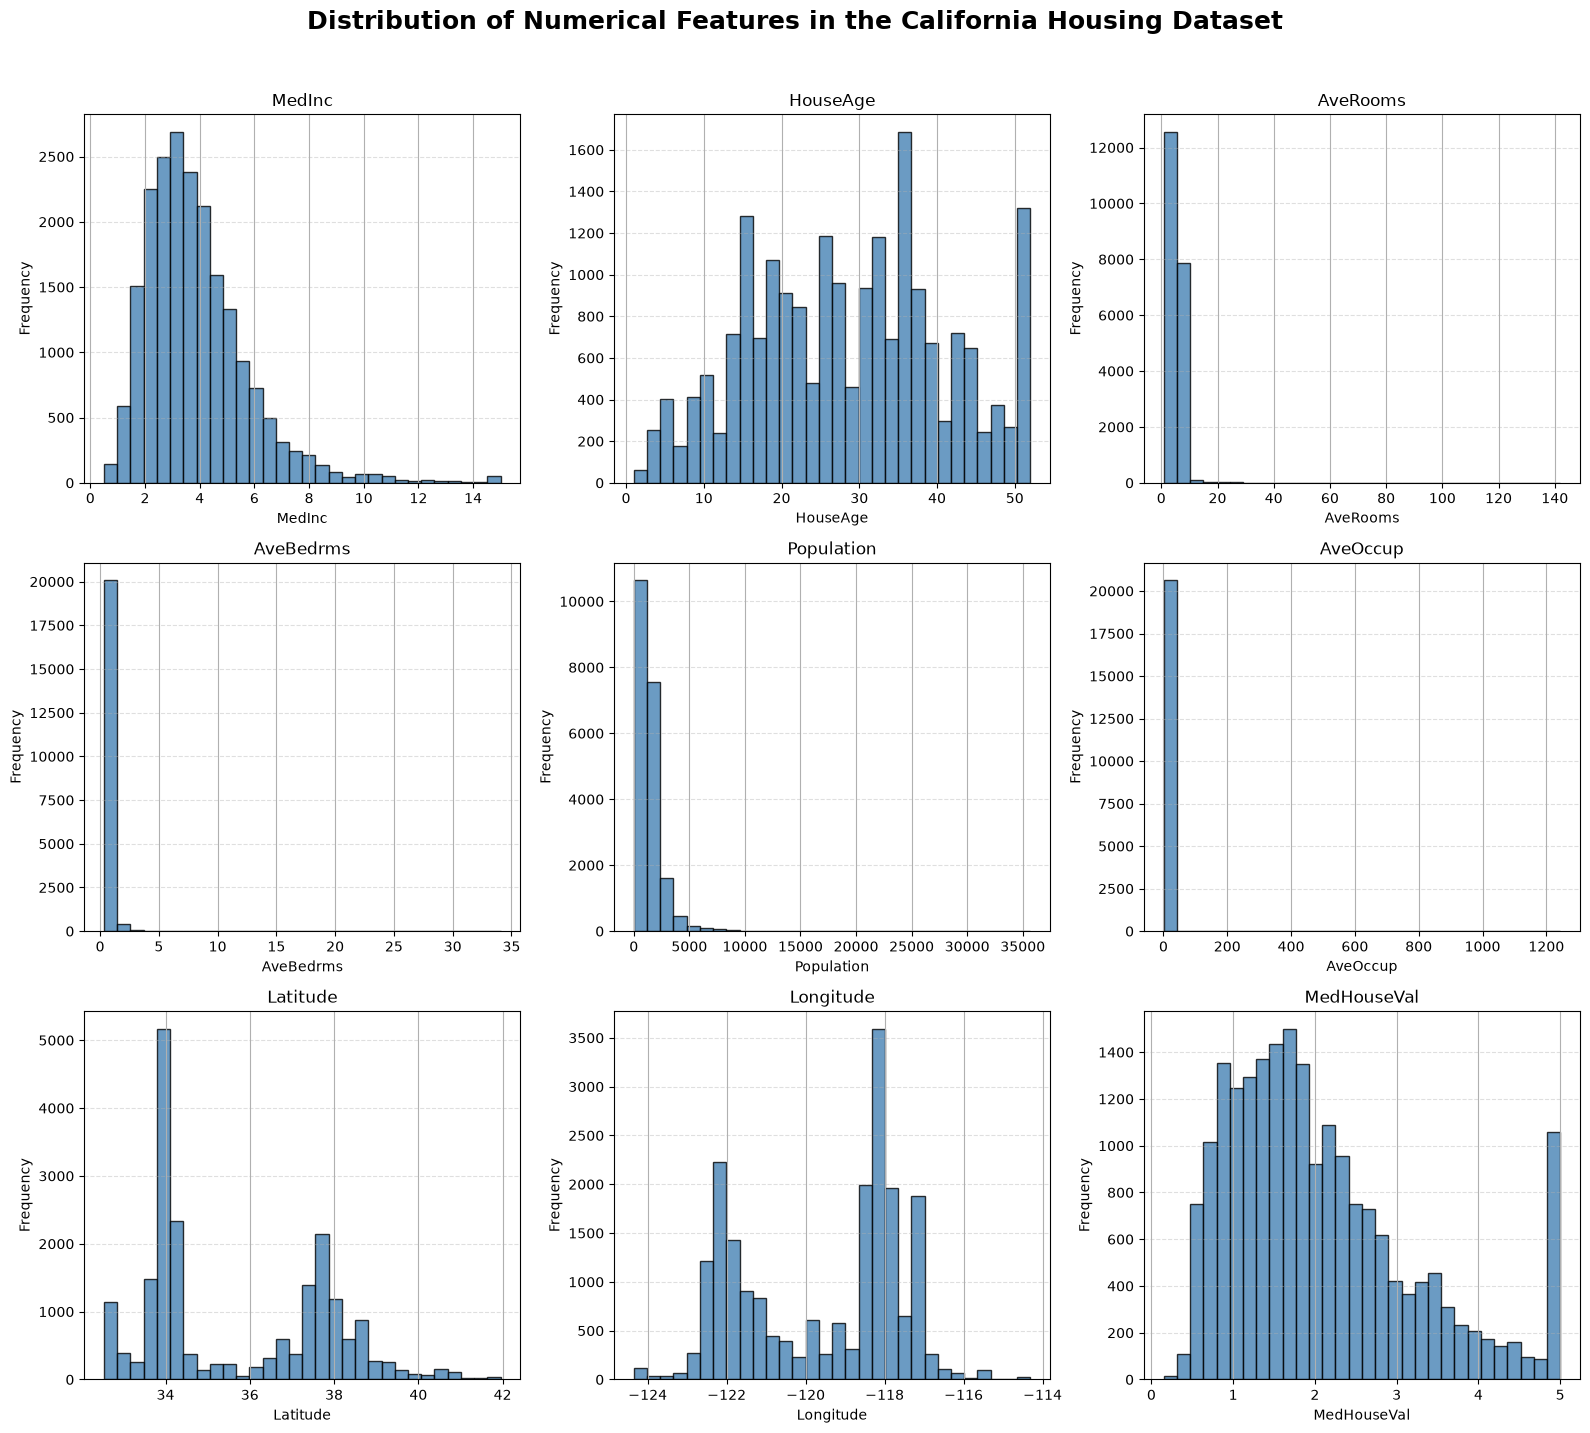

In [23]:
# Create histograms for all numerical features
axes = df[numerical_columns].hist(
    figsize=(16, 14),
    bins=30,
    edgecolor="black",
    color="steelblue",
    alpha=0.8
)

# Add a main title
plt.suptitle(
    "Distribution of Numerical Features in the California Housing Dataset",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

# Improve individual subplot formatting
for ax in axes.flatten():
    ax.set_xlabel(ax.get_title(), fontsize=10)
    ax.set_ylabel("Frequency", fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### 3.2.2 Distribution of the Target Variable

The target variable, `MedHouseVal`, represents the median house value in units of $100,000. Examining its distribution helps us understand the range and concentration of house values that the regression models will attempt to predict.

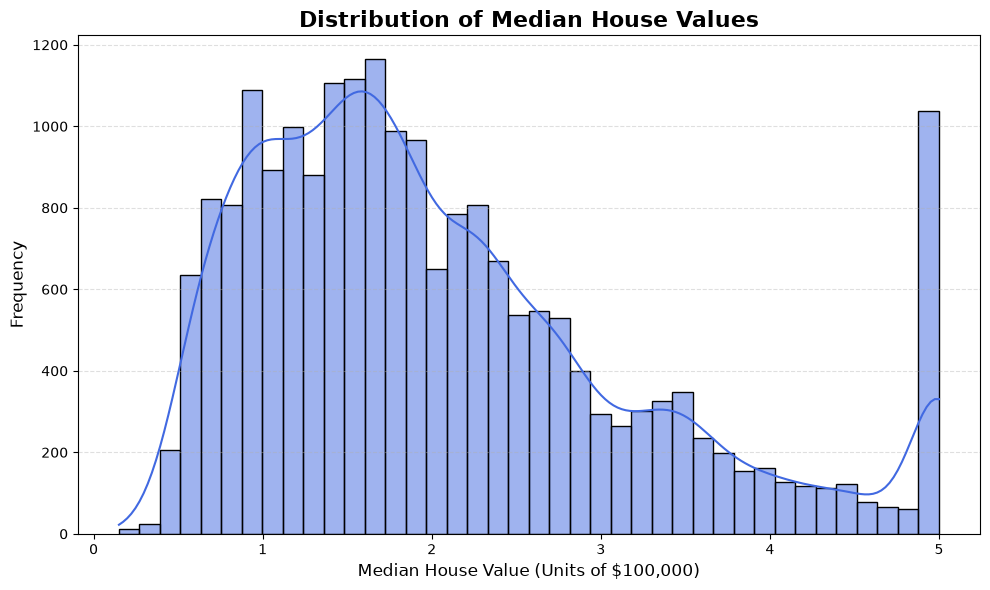

In [24]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="MedHouseVal",
    bins=40,
    kde=True,
    color="royalblue",
    edgecolor="black"
)

plt.title(
    "Distribution of Median House Values",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Median House Value (Units of $100,000)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### 3.2.3 Investigation of the Target Variable's Upper Boundary

The histogram shows a noticeable concentration of observations at the upper end of the `MedHouseVal` distribution. To investigate this pattern, the maximum target value and the number of observations equal to that maximum are calculated.

In [25]:
# Investigate the maximum value of the target variable
max_house_value = df["MedHouseVal"].max()
max_value_count = (df["MedHouseVal"] == max_house_value).sum()
max_value_percentage = (max_value_count / len(df)) * 100

print(f"Maximum MedHouseVal: {max_house_value}")
print(f"Number of observations at the maximum: {max_value_count}")
print(f"Percentage of observations at the maximum: {max_value_percentage:.2f}%")

Maximum MedHouseVal: 5.00001
Number of observations at the maximum: 965
Percentage of observations at the maximum: 4.68%


### Interpretation of the Target Distribution

The `MedHouseVal` distribution shows a noticeable concentration of observations at its maximum recorded value of **5.00001**, corresponding to approximately  **\$500,001** because the target is expressed in units of $100,000.

A total of **965 observations**, representing approximately **4.68% of the dataset**, have exactly this maximum target value. This strong accumulation at a single upper boundary is consistent with the dataset's target being **top-coded (capped) near $500,000**, meaning houses above the threshold are not represented by their full underlying values.

This is an important modeling limitation. Because different high-value areas may share the same recorded maximum target value, a regression model cannot learn distinctions among their true values beyond the cap. The concentration at the upper boundary may therefore affect model fit and prediction accuracy, particularly for expensive housing areas.

The target distribution is also moderately right-skewed (skewness = **0.978**), indicating that higher-valued observations extend the upper side of the distribution. The combination of skewness and the upper-value concentration should be considered when interpreting subsequent regression results.

### 3.2.4 Box Plot Analysis for Potential Outliers

Box plots are used to visually identify potential outliers based on the interquartile range (IQR). Observations appearing beyond the whiskers are statistical outliers; however, they are not necessarily incorrect values.

Because the numerical features have very different scales, separate box plots are created for selected variables rather than plotting all features on a single shared axis. Particular attention is given to `AveRooms`, `AveBedrms`, and `AveOccup`, which showed exceptionally high positive skewness during the statistical analysis.

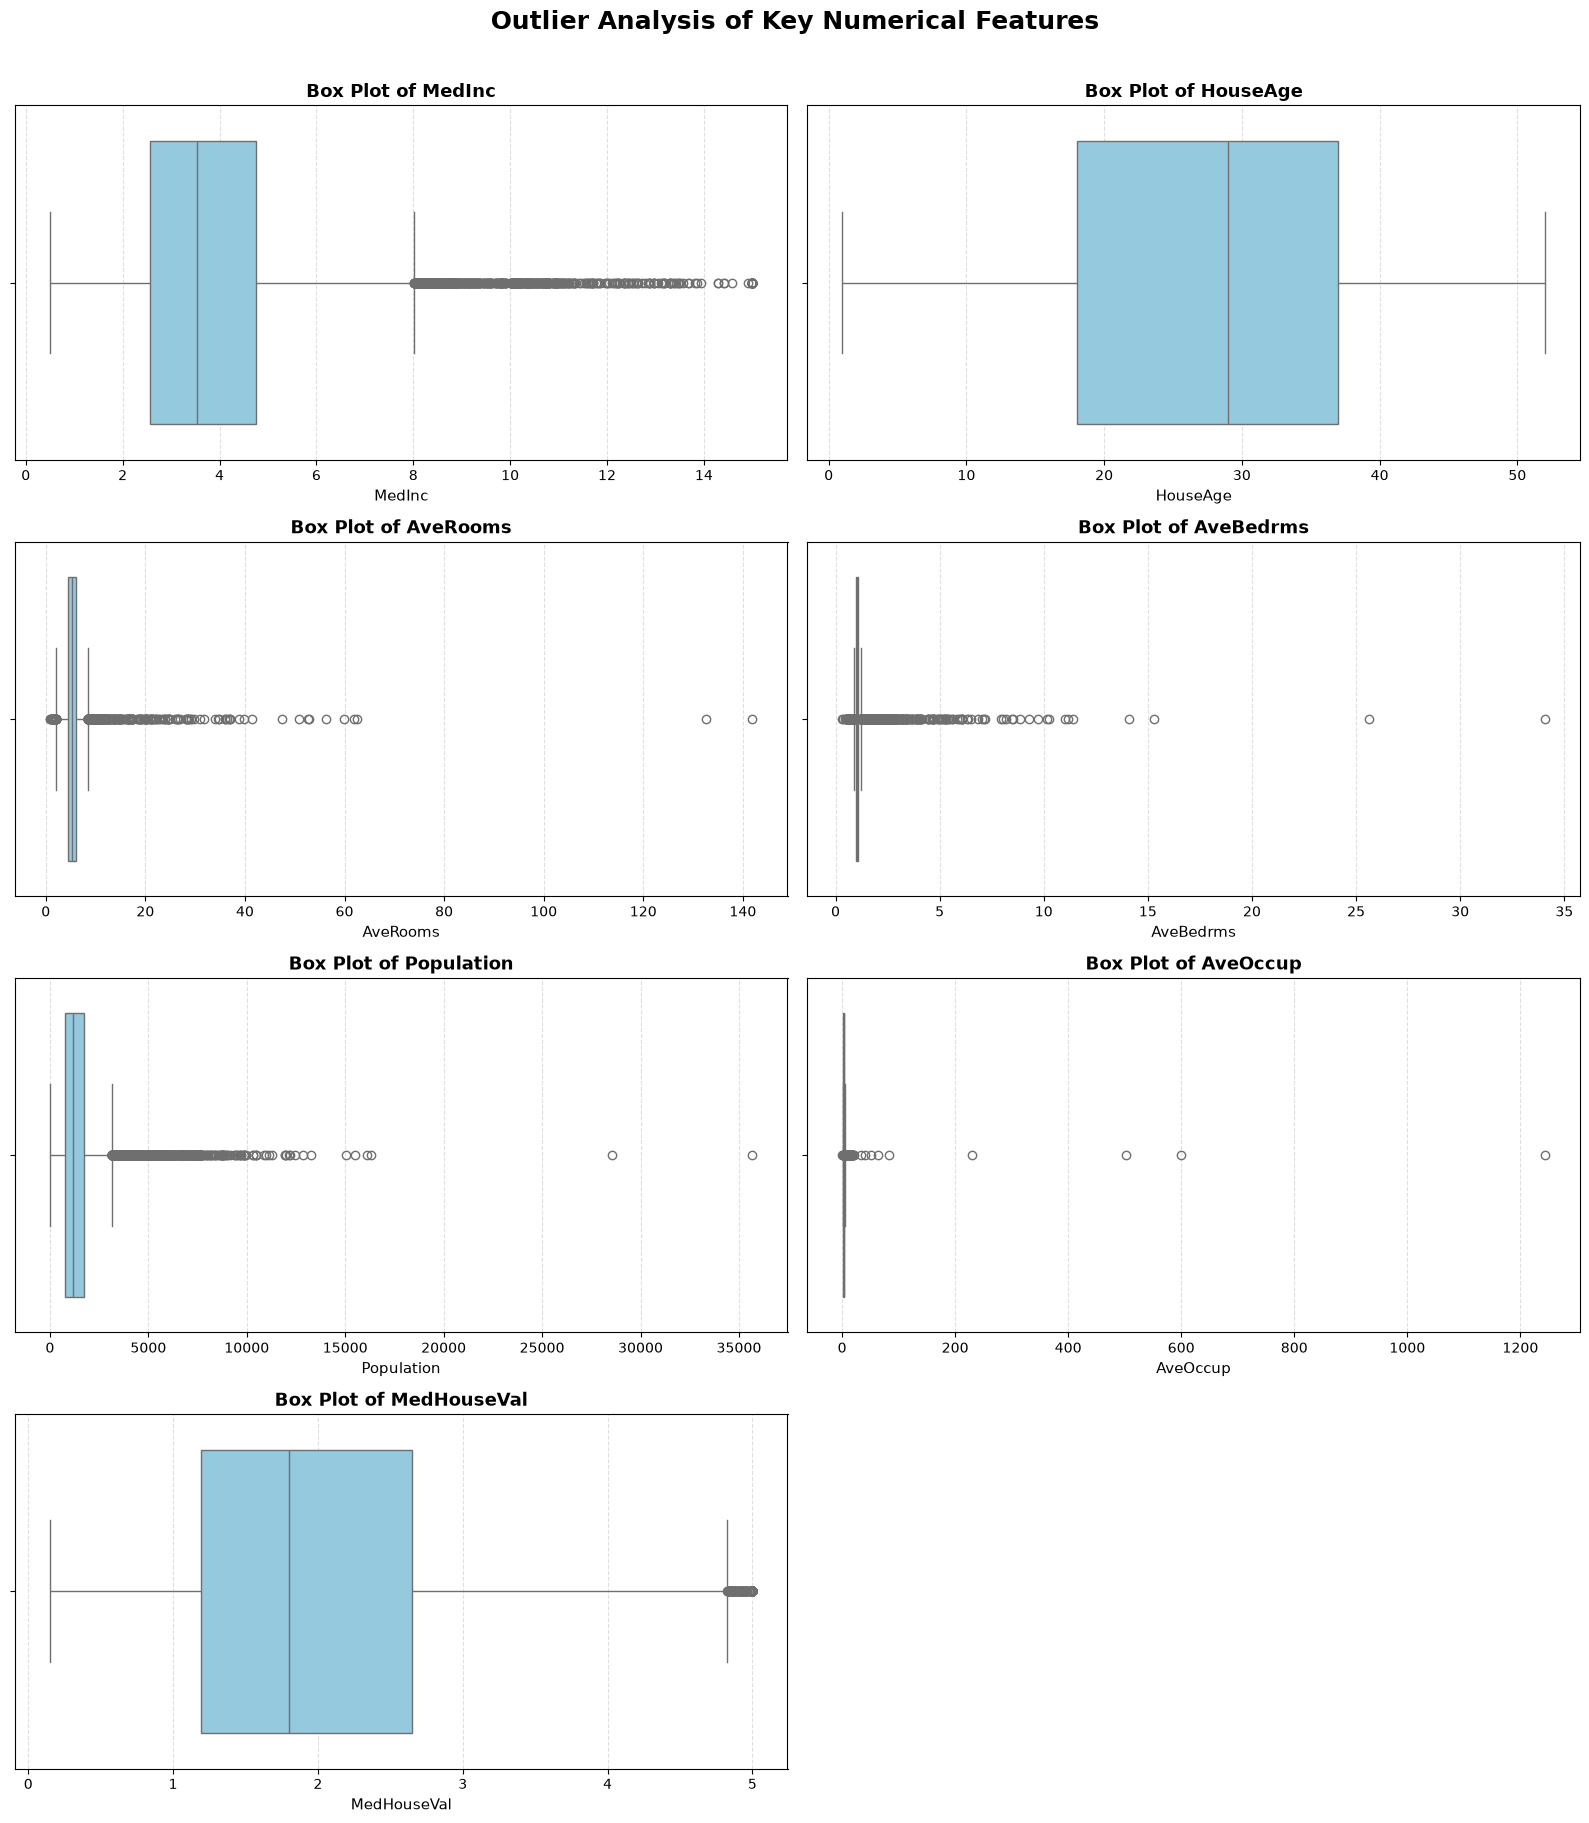

In [26]:
# Select key features for outlier visualization
boxplot_features = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup",
    "MedHouseVal"
]

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for i, feature in enumerate(boxplot_features):
    sns.boxplot(
        x=df[feature],
        ax=axes[i],
        color="skyblue"
    )
    
    axes[i].set_title(
        f"Box Plot of {feature}",
        fontsize=13,
        fontweight="bold"
    )
    axes[i].set_xlabel(feature, fontsize=11)
    axes[i].grid(axis="x", linestyle="--", alpha=0.4)

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.suptitle(
    "Outlier Analysis of Key Numerical Features",
    fontsize=18,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

### 3.2.5 Quantitative Outlier Analysis Using the IQR Method

To complement the box plots, potential outliers are quantified using the **1.5 × IQR rule**. For each numerical variable, observations below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR` are counted as potential statistical outliers.

These observations are identified for analytical purposes only and are not automatically removed, since extreme values may represent genuine characteristics of particular California block groups.

In [27]:
# Quantify potential outliers using the 1.5 × IQR rule
outlier_summary = []

for feature in numerical_columns:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier_mask = (
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    )
    
    outlier_count = outlier_mask.sum()
    outlier_percentage = (outlier_count / len(df)) * 100
    
    outlier_summary.append({
        "Feature": feature,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage (%)": outlier_percentage
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df = outlier_summary_df.sort_values(
    by="Outlier Percentage (%)",
    ascending=False
).reset_index(drop=True)

outlier_summary_df.round(3)

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,AveBedrms,0.866,1.240,1424,6.899
1,Population,-620.000,3132.000,1196,5.795
2,MedHouseVal,-0.981,4.824,1071,5.189
3,AveOccup,1.151,4.561,711,3.445
4,MedInc,-0.706,8.013,681,3.299
5,AveRooms,2.023,8.470,511,2.476
6,HouseAge,-10.500,65.500,0,0.000
7,Latitude,28.260,43.380,0,0.000
8,Longitude,-127.485,-112.325,0,0.000


### Interpretation of Potential Outliers

The IQR-based analysis confirms that several numerical variables contain potential statistical outliers, although their presence does not necessarily indicate data errors.

- **`AveBedrms` has the highest proportion of IQR-based outliers**, with **1,424 observations (6.90%)** outside the calculated bounds. Combined with its very high positive skewness (31.317), this indicates a relatively small number of block groups with unusually high or low average bedroom-to-household ratios.

- **`Population` contains 1,196 potential outliers (5.80%)**, primarily representing block groups with populations above the upper IQR boundary of 3,132. The negative lower bound (-620) is a mathematical result of the IQR rule and does not imply that negative population values exist; the earlier validity checks confirmed that all population values are non-negative.

- The target variable, **`MedHouseVal`, contains 1,071 potential outliers (5.19%)** according to the IQR rule. This is influenced by high-value housing areas and the concentration of observations at the dataset's upper target boundary of 5.00001.

- **`AveOccup` contains 711 potential outliers (3.45%)**. Its exceptionally high skewness of 97.640 suggests that a small number of observations are extremely large, even though the overall percentage classified as outliers is relatively modest.

- **`MedInc` and `AveRooms` contain 681 (3.30%) and 511 (2.48%) potential outliers**, respectively, indicating the presence of some unusually high-income areas and unusual average room counts.

- **`HouseAge`, `Latitude`, and `Longitude` have no observations outside their respective IQR-based boundaries**.

No potential outliers are removed at this stage. The earlier data-quality checks found no logically impossible values, and extreme observations may represent genuine characteristics of unusual California block groups. Removing them without sufficient evidence could discard valid information and alter the population represented by the dataset. Their possible influence on regression performance will instead be considered when interpreting model results and residuals.

### 3.2.6 Correlation Analysis

Correlation analysis measures the strength and direction of the linear relationship between numerical variables. The Pearson correlation coefficient ranges from **-1 to +1**:

- A value close to **+1** indicates a strong positive linear relationship.
- A value close to **-1** indicates a strong negative linear relationship.
- A value close to **0** indicates little or no linear relationship.

Correlation does not imply causation; however, it can help identify features that may be useful predictors in a linear regression model.

In [28]:
# Calculate the Pearson correlation matrix
correlation_matrix = df[numerical_columns].corr()

correlation_matrix.round(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000,-0.119,0.327,-0.062,0.005,0.019,-0.080,-0.015,0.688
HouseAge,-0.119,1.000,-0.153,-0.078,-0.296,0.013,0.011,-0.108,0.106
AveRooms,0.327,-0.153,1.000,0.848,-0.072,-0.005,0.106,-0.028,0.152
AveBedrms,-0.062,-0.078,0.848,1.000,-0.066,-0.006,0.070,0.013,-0.047
Population,0.005,-0.296,-0.072,-0.066,1.000,0.070,-0.109,0.100,-0.025
AveOccup,0.019,0.013,-0.005,-0.006,0.070,1.000,0.002,0.002,-0.024
Latitude,-0.080,0.011,0.106,0.070,-0.109,0.002,1.000,-0.925,-0.144
Longitude,-0.015,-0.108,-0.028,0.013,0.100,0.002,-0.925,1.000,-0.046
MedHouseVal,0.688,0.106,0.152,-0.047,-0.025,-0.024,-0.144,-0.046,1.000


### 3.2.7 Correlation Heatmap

The heatmap below visualizes the Pearson correlation coefficients between all numerical variables. Annotated values make it easier to identify strong positive and negative relationships, while the color scale provides a quick visual comparison of correlation strength.

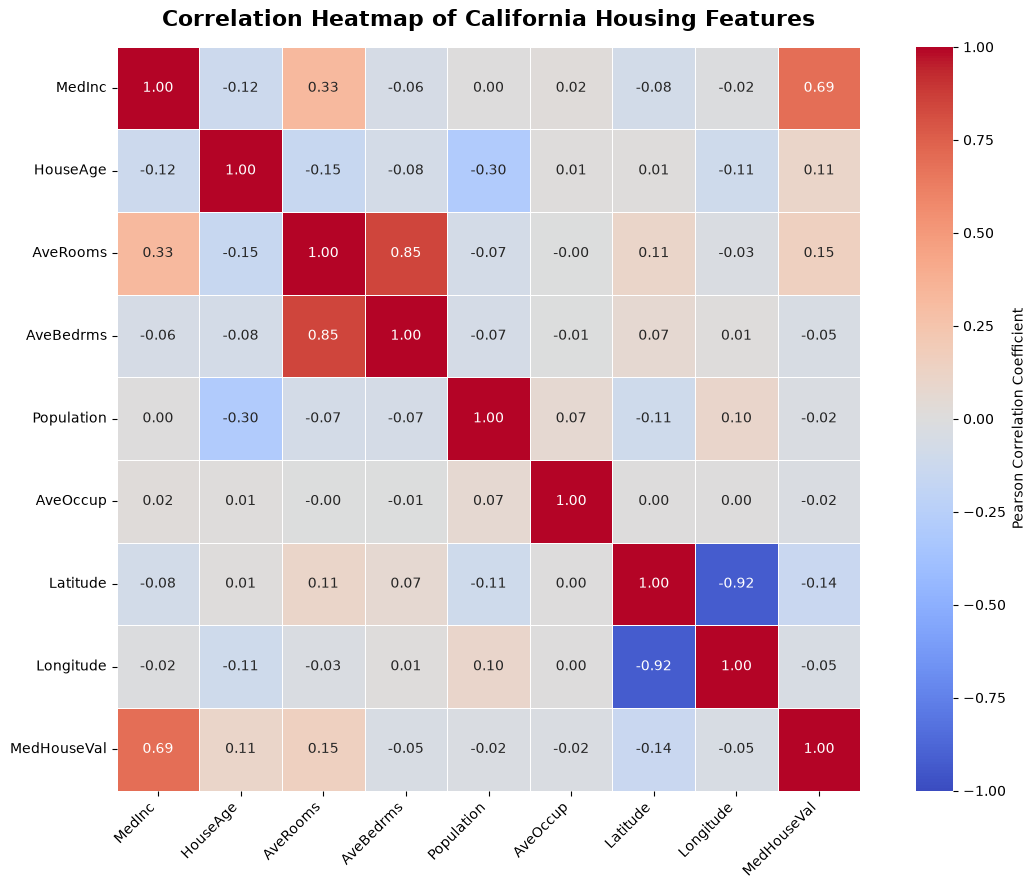

In [29]:
# Create a full correlation heatmap
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Pearson Correlation Coefficient"}
)

plt.title(
    "Correlation Heatmap of California Housing Features",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 3.2.8 Correlation of Features with Median House Value

To identify variables with the strongest linear relationships with the target, the correlation coefficients between each predictor and `MedHouseVal` are extracted and ranked.

The absolute correlation is also calculated because both strong positive and strong negative relationships can potentially provide useful predictive information.

In [30]:
# Extract correlations between predictor features and the target
target_correlations = (
    correlation_matrix["MedHouseVal"]
    .drop("MedHouseVal")
    .to_frame(name="Correlation")
)

# Add absolute correlation for ranking purposes
target_correlations["Absolute Correlation"] = (
    target_correlations["Correlation"].abs()
)

# Rank features from strongest to weakest absolute correlation
target_correlations = target_correlations.sort_values(
    by="Absolute Correlation",
    ascending=False
)

target_correlations.round(3)

,Correlation,Absolute Correlation
MedInc,0.688,0.688
AveRooms,0.152,0.152
Latitude,-0.144,0.144
HouseAge,0.106,0.106
AveBedrms,-0.047,0.047
Longitude,-0.046,0.046
Population,-0.025,0.025
AveOccup,-0.024,0.024


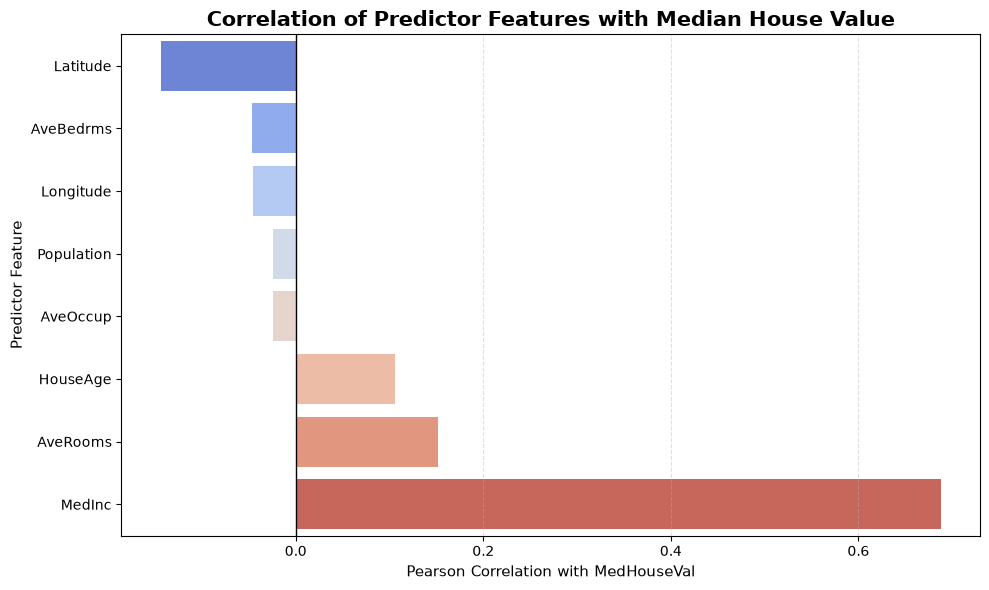

In [31]:
# Plot correlations between predictor features and the target
correlation_plot_data = target_correlations.sort_values(
    by="Correlation",
    ascending=True
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=correlation_plot_data.reset_index(),
    x="Correlation",
    y="index",
    hue="index",
    palette="coolwarm",
    legend=False
)

plt.axvline(0, color="black", linewidth=1)

plt.title(
    "Correlation of Predictor Features with Median House Value",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Pearson Correlation with MedHouseVal", fontsize=11)
plt.ylabel("Predictor Feature", fontsize=11)
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Interpretation of Correlation Analysis

The correlation analysis reveals substantial differences in the strength of linear relationships between the predictor variables and median house value.

- **`MedInc` has by far the strongest correlation with `MedHouseVal` (r = 0.688)**. This moderately strong positive relationship indicates that block groups with higher median household incomes generally tend to have higher median house values. Among the available predictors, `MedInc` is therefore the strongest candidate for the **Simple Linear Regression** model.

- **`AveRooms` has a weak positive correlation (r = 0.152)** with median house value, suggesting that areas with more rooms per household tend to have somewhat higher house values, although the linear relationship is relatively weak.

- **`Latitude` has a weak negative correlation (r = -0.144)**. This suggests that house values vary with north-south geographic location, although latitude alone cannot fully represent California's spatial housing patterns.

- **`HouseAge` shows a weak positive correlation (r = 0.106)** with the target, indicating only a limited linear relationship between median housing age and house value.

- **`AveBedrms` (r = -0.047), `Longitude` (r = -0.046), `Population` (r = -0.025), and `AveOccup` (r = -0.024)** each have very weak individual linear correlations with `MedHouseVal`.

- Among the predictors, **`AveOccup` has the weakest absolute linear correlation with the target (|r| = 0.024)**, closely followed by `Population` (|r| = 0.025).

An important limitation of this analysis is that **Pearson correlation measures only linear relationships between individual variables**. A feature with weak marginal correlation may still improve predictions when combined with other variables or when its relationship with house value is nonlinear. Geographic variables provide a particularly important example: `Latitude` and `Longitude` individually show relatively weak correlations with house value, but together they encode location, which may contain valuable information about regional and coastal housing-price patterns.

Therefore, correlation will be used as one source of evidence along with domain knowledge and subsequent model evaluation when selecting predictors for Multiple Linear Regression.

### 3.2.9 Relationships Between Key Predictors and Median House Value

Scatter plots with fitted linear trend lines are used to visually examine relationships between selected predictor variables and `MedHouseVal`.

The selected features include `MedInc`, which has the strongest linear correlation with the target, as well as `AveRooms` and `HouseAge`, which represent important housing characteristics. These visualizations help determine whether the relationships appear linear and reveal patterns that correlation coefficients alone may not fully capture.

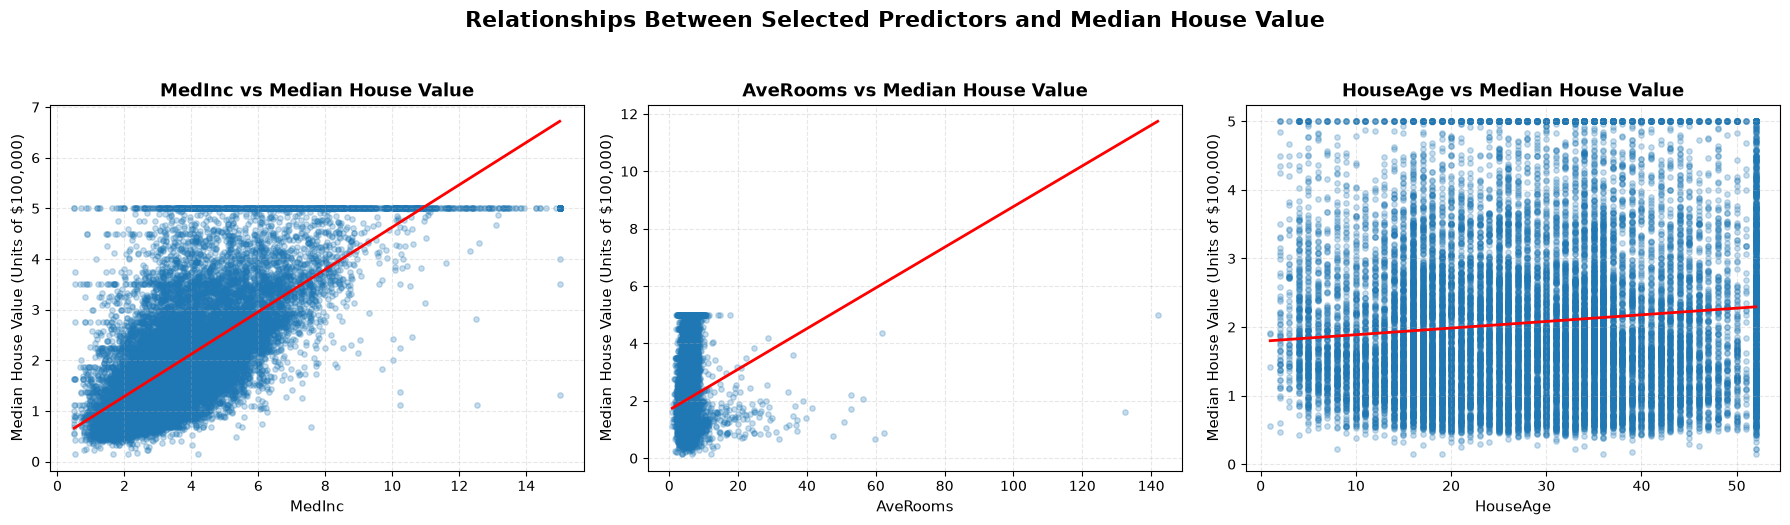

In [32]:
# Selected predictors for scatter plot analysis
scatter_features = ["MedInc", "AveRooms", "HouseAge"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, scatter_features):
    sns.regplot(
        data=df,
        x=feature,
        y="MedHouseVal",
        ax=ax,
        ci=None,
        scatter_kws={"alpha": 0.25, "s": 15},
        line_kws={"color": "red", "linewidth": 2}
    )

    ax.set_title(
        f"{feature} vs Median House Value",
        fontsize=13,
        fontweight="bold"
    )
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel(
        "Median House Value (Units of $100,000)",
        fontsize=11
    )
    ax.grid(linestyle="--", alpha=0.3)

plt.suptitle(
    "Relationships Between Selected Predictors and Median House Value",
    fontsize=16,
    fontweight="bold",
    y=1.04
)

plt.tight_layout()
plt.show()

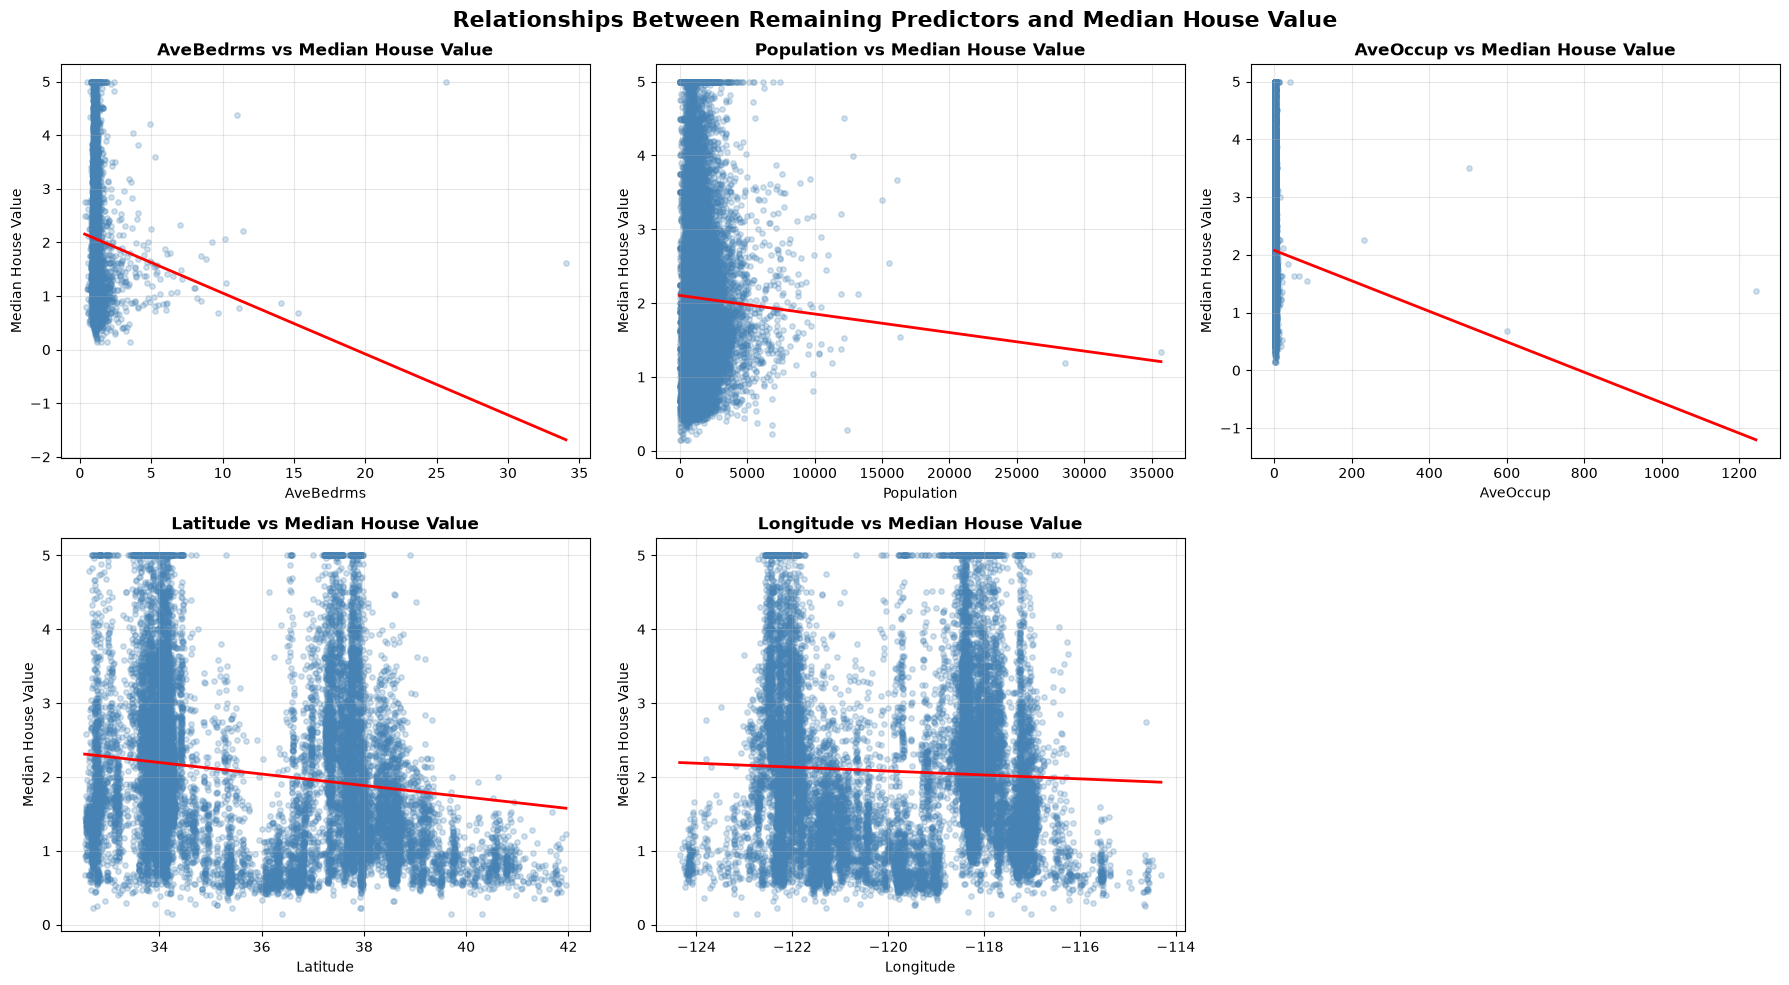

In [33]:
remaining_features = [
    "AveBedrms",
    "Population",
    "AveOccup",
    "Latitude",
    "Longitude"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feature in zip(axes, remaining_features):
    sns.regplot(
        data=df,
        x=feature,
        y="MedHouseVal",
        ax=ax,
        ci=None,
        scatter_kws={
            "alpha": 0.25,
            "s": 15,
            "color": "steelblue"
        },
        line_kws={
            "color": "red",
            "linewidth": 2
        }
    )

    ax.set_title(
        f"{feature} vs Median House Value",
        fontsize=12,
        fontweight="bold"
    )
    ax.set_xlabel(feature)
    ax.set_ylabel("Median House Value")
    ax.grid(alpha=0.3)

# Hide the unused subplot
axes[-1].axis("off")

plt.suptitle(
    "Relationships Between Remaining Predictors and Median House Value",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### 3.2.10 Geographic Pattern of Median House Values

Although latitude and longitude have relatively weak individual Pearson correlations with `MedHouseVal`, their combination represents geographic location. Plotting longitude against latitude and encoding median house value using color helps reveal spatial patterns that cannot be captured by separate one-dimensional correlation coefficients.

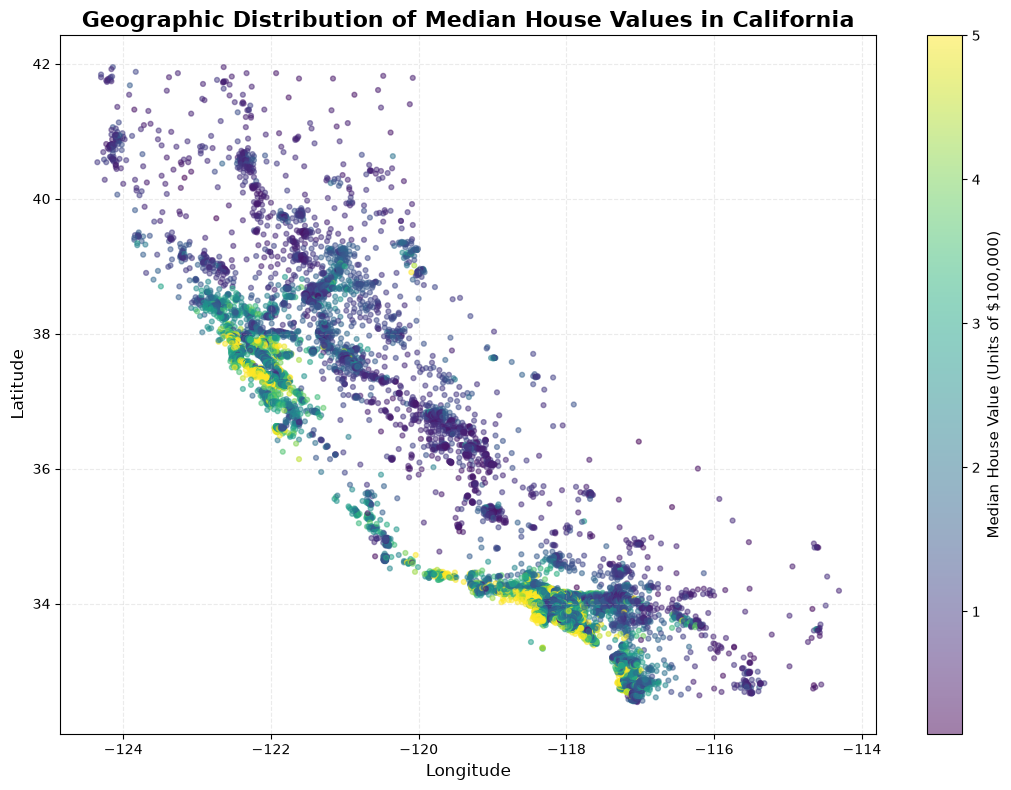

In [34]:
plt.figure(figsize=(11, 8))

scatter = plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["MedHouseVal"],
    cmap="viridis",
    alpha=0.5,
    s=12
)

cbar = plt.colorbar(scatter)
cbar.set_label(
    "Median House Value (Units of $100,000)",
    fontsize=11
)

plt.title(
    "Geographic Distribution of Median House Values in California",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.grid(linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

### 3.2.11 Pairwise Relationships Among Selected Features

A pair plot is used to examine distributions and pairwise relationships among selected important variables. The subset includes the target, the strongest correlated predictor (`MedInc`), housing characteristics (`HouseAge` and `AveRooms`), and geographic coordinates (`Latitude` and `Longitude`).

Using a focused subset keeps the visualization readable while allowing important relationships and possible feature interactions to be explored.

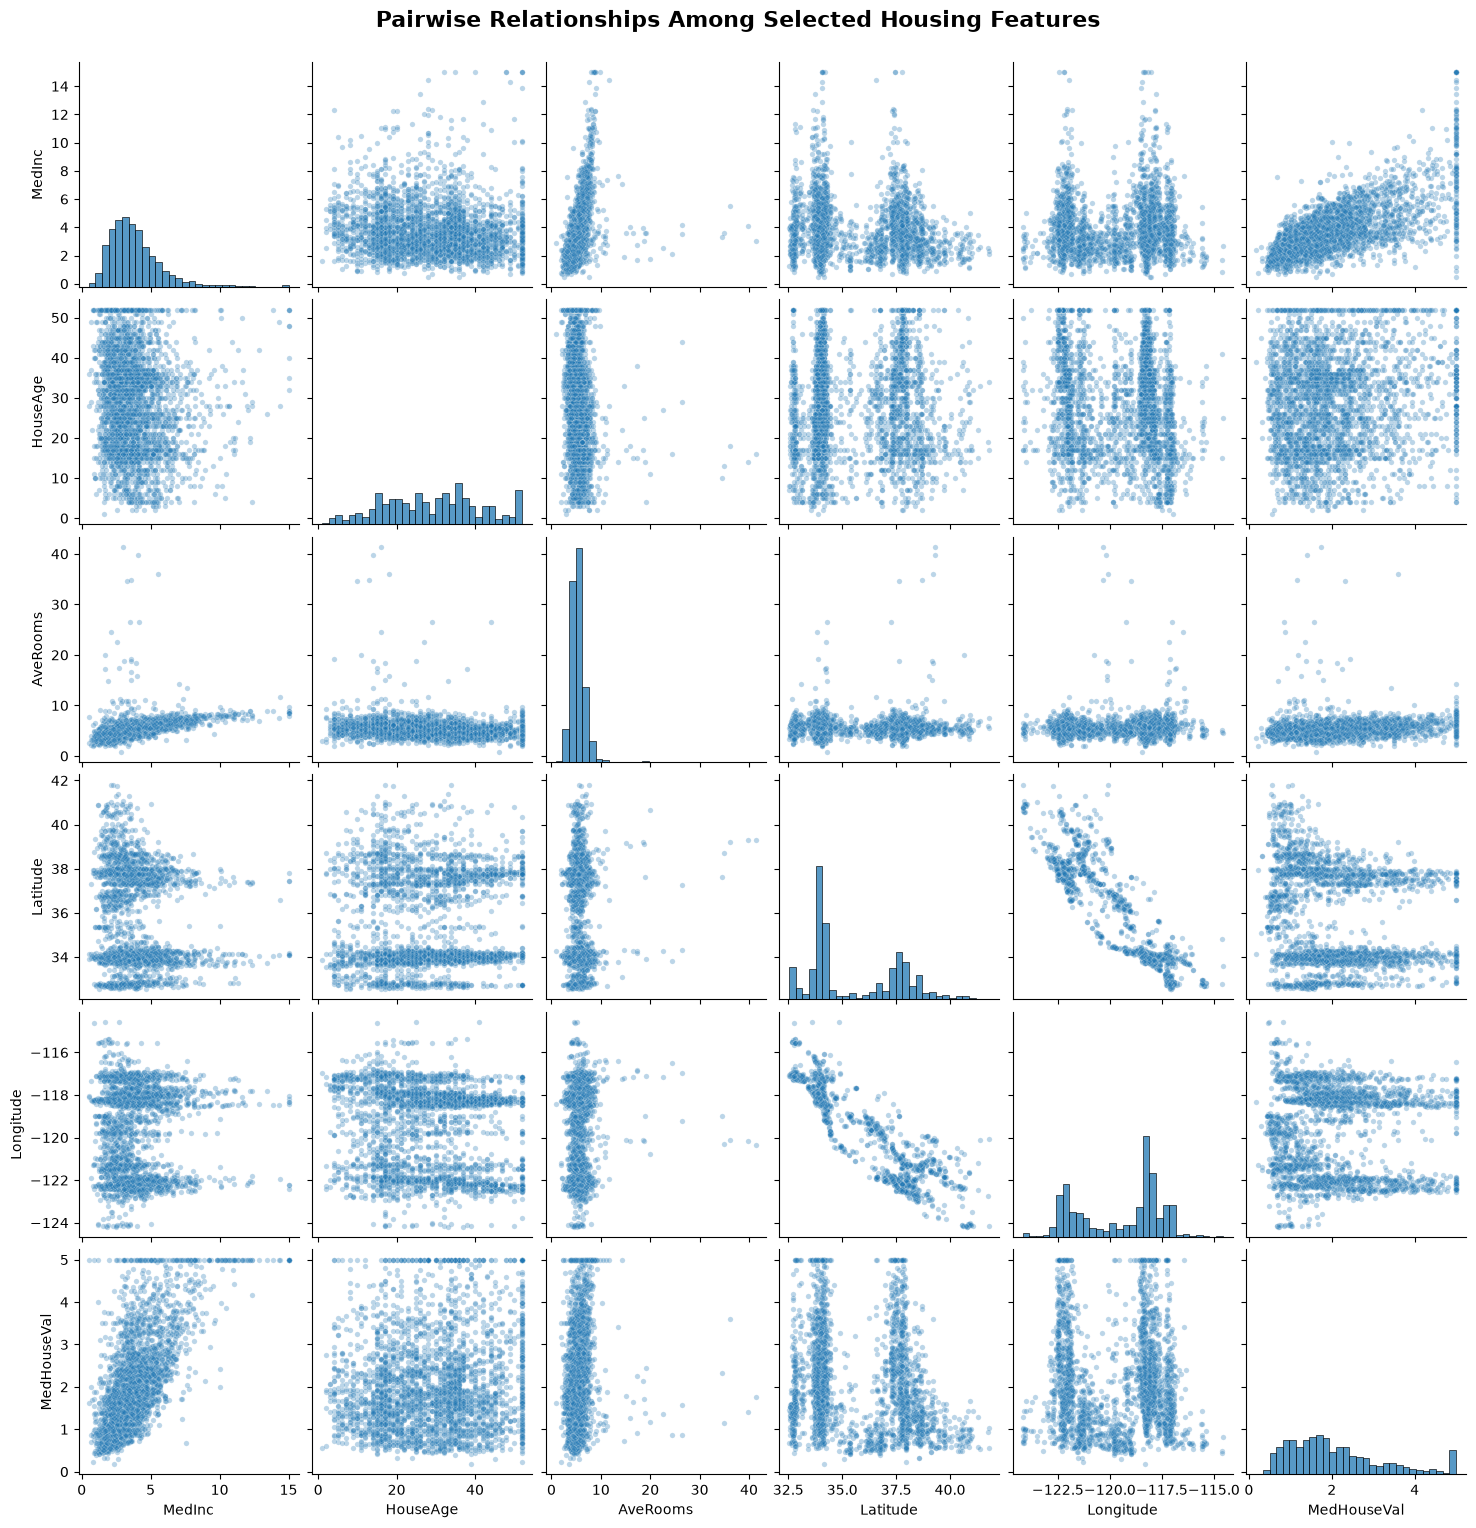

In [35]:
# Select a focused subset of important variables
pairplot_features = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "Latitude",
    "Longitude",
    "MedHouseVal"
]

# Sample observations for readability and faster rendering
pairplot_sample = df[pairplot_features].sample(
    n=3000,
    random_state=42
)

sns.pairplot(
    pairplot_sample,
    diag_kind="hist",
    plot_kws={
        "alpha": 0.3,
        "s": 15
    },
    diag_kws={
        "bins": 30,
        "edgecolor": "black"
    }
)

plt.suptitle(
    "Pairwise Relationships Among Selected Housing Features",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.show()

### Interpretation of Multivariate and Geographic Patterns

The geographic visualization reveals clear spatial variation in median house values across California. Higher-value observations are concentrated in particular geographic regions, especially along parts of the coast, while many inland locations show comparatively lower house values. This demonstrates that geographic location contains useful predictive information.

Importantly, `Latitude` and `Longitude` show only weak individual linear correlations with `MedHouseVal`, but their combined spatial pattern is considerably more informative. This illustrates a limitation of relying exclusively on univariate Pearson correlation for feature selection: variables with weak individual linear relationships may still contribute useful information when considered jointly with other predictors.

The pair plot further supports the strong positive relationship between `MedInc` and `MedHouseVal` and highlights the extreme values present in `AveRooms`. It also shows structured relationships between the geographic coordinates and confirms the concentration of observations at the upper boundary of `MedHouseVal`.

These findings suggest that median income is likely to be the strongest individual predictor for Simple Linear Regression, while a Multiple Linear Regression model may benefit from combining socioeconomic, housing, and geographic information.

# Part 4 — Insights & Observations

The following observations summarize the key findings from the descriptive statistics, distribution analysis, outlier analysis, correlation analysis, and visual exploration. Each observation is supported by numerical results or visual evidence from the preceding EDA.

### 1. Median income is the strongest individual linear predictor of house value

`MedInc` has the strongest correlation with `MedHouseVal`, with a Pearson correlation coefficient of **r = 0.688**. The scatter plot also shows a clear positive trend, indicating that California block groups with higher median household incomes generally tend to have higher median house values.

### 2. Average occupancy has the weakest linear correlation with house value

Among all predictor variables, `AveOccup` has the weakest absolute correlation with `MedHouseVal` (**r = -0.024**), closely followed by `Population` (**r = -0.025**). This suggests that these variables have very limited individual linear relationships with house value, although they could still contain useful nonlinear or conditional information.

### 3. The target variable shows evidence of an upper-value cap

The maximum recorded `MedHouseVal` is **5.00001**, corresponding to approximately **$500,001**. A total of **965 observations (4.68%)** occur exactly at this maximum value, producing a visible spike in the target histogram and a horizontal concentration in scatter plots. This is consistent with an upper-coded target and represents an important limitation when modeling expensive housing areas.

### 4. Median house value is moderately right-skewed

`MedHouseVal` has a skewness coefficient of **0.978**, with a mean of **2.069** and a median of **1.797**. This indicates a moderately right-skewed distribution, where higher-valued housing observations extend the upper side of the distribution.

### 5. Average occupancy contains extremely influential upper-tail observations

`AveOccup` has the highest skewness coefficient in the dataset at **97.640**, despite having only **711 IQR-based potential outliers (3.45%)**. This suggests that a relatively small number of exceptionally large occupancy values create an extremely long right tail and may disproportionately influence models that are sensitive to extreme observations.

### 6. Average bedroom and room counts are highly right-skewed

`AveBedrms` and `AveRooms` have skewness values of **31.317** and **20.698**, respectively. The box plots and scatter plots confirm the presence of extreme values, with `AveBedrms` having **1,424 potential outliers (6.90%)** and `AveRooms` having **511 (2.48%)**, according to the 1.5 × IQR rule.

### 7. Population also exhibits substantial variability and right skewness

`Population` has a skewness coefficient of **4.936**, and its mean (**1,425.477**) is considerably greater than its median (**1,166**). The IQR analysis identifies **1,196 observations (5.80%)** as potential statistical outliers, indicating that some block groups have substantially larger populations than a typical block group.

### 8. House age has a nearly symmetric distribution and a weak relationship with price

`HouseAge` has a skewness coefficient of only **0.060**, with a mean of **28.639 years** and a median of **29 years**, indicating an approximately symmetric distribution. However, its correlation with `MedHouseVal` is only **r = 0.106**, and the scatter plot shows only a slight positive linear trend.

### 9. Average number of rooms alone is not a strong predictor of house value

Although `AveRooms` has a positive correlation with `MedHouseVal`, the relationship is relatively weak (**r = 0.152**). Its scatter plot is also strongly affected by extreme room-count observations, suggesting that average rooms alone is insufficient to explain housing-price variation and that its relationship with price may be more complex than a simple linear trend.

### 10. Geographic coordinates reveal information that individual correlations miss

`Latitude` and `Longitude` have relatively weak individual correlations with `MedHouseVal` (**r = -0.144** and **r = -0.046**, respectively). However, the geographic scatter plot reveals clear spatial clustering of house values, with higher-value observations concentrated in particular geographic regions, especially along parts of the California coast. This shows that the two coordinates can be more informative when considered jointly.

### 11. Correlation alone should not determine feature selection

The geographic analysis demonstrates that a low individual Pearson correlation does not necessarily imply that a feature is useless for prediction. Pearson correlation measures only pairwise linear association, so variables such as `Latitude` and `Longitude` may provide valuable information when used together or in combination with socioeconomic and housing characteristics.

### 12. Median income is the strongest candidate for Simple Linear Regression, while multiple features may improve prediction

Based on its substantially higher correlation with the target (**r = 0.688**) and the clear positive pattern observed in the scatter plot, `MedInc` is the most appropriate feature for the Simple Linear Regression model. For Multiple Linear Regression, combining income with housing and geographic variables may capture additional variation in house values that median income alone cannot explain.

### Overall EDA Finding

The exploratory analysis indicates that California housing values are influenced by a combination of socioeconomic, housing, and geographic factors. `MedInc` stands out as the strongest individual linear predictor, but the geographic visualization demonstrates that meaningful predictive information can exist even when individual correlation coefficients are weak. Extreme values and the upper cap in the target variable are also important considerations that may affect the performance and interpretation of regression models.

# Part 5 — Simple Linear Regression

Simple Linear Regression models the linear relationship between one predictor variable and a continuous target variable.

For this analysis, **`MedInc` (Median Income)** is selected as the predictor and **`MedHouseVal` (Median House Value)** as the target.

`MedInc` was selected because it has the **strongest Pearson correlation with the target (r = 0.688)** among all available predictor variables. The EDA scatter plot also demonstrated a clear positive relationship between median income and median house value.

The objective is to determine how effectively median income alone can predict median house value and establish a baseline that can later be compared with Multiple Linear Regression.

## 5.1 Feature and Target Selection

The predictor `X` contains only `MedInc`, while the target `y` contains `MedHouseVal`.

Keeping `X` as a two-dimensional DataFrame ensures that it has the format expected by Scikit-learn's regression model.

In [36]:
# Select the predictor feature and target variable
X_simple = df[["MedInc"]]
y = df["MedHouseVal"]

print(f"Predictor shape: {X_simple.shape}")
print(f"Target shape: {y.shape}")

Predictor shape: (20640, 1)
Target shape: (20640,)


## 5.2 Train-Test Split

The dataset is divided into **80% training data** and **20% testing data** using `train_test_split`.

The model learns the relationship between median income and house value from the training set. The test set remains unseen during training and is used to evaluate how well the model generalizes to new observations.

A `random_state` of 33 is used to make the split reproducible.

In [37]:
# Split the data into 80% training and 20% testing sets
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple,
    y,
    test_size=0.20,
    random_state=33
)

print(f"Training observations: {X_train_simple.shape[0]}")
print(f"Testing observations: {X_test_simple.shape[0]}")

Training observations: 16512
Testing observations: 4128


## 5.3 Model Training

A Simple Linear Regression model is trained using the training data. The fitted model estimates an intercept and a coefficient (slope) that describe the linear relationship between `MedInc` and `MedHouseVal`.

In [38]:
# Initialize and train the Simple Linear Regression model
simple_lr = LinearRegression()

simple_lr.fit(
    X_train_simple,
    y_train_simple
)

# Extract model parameters
simple_intercept = simple_lr.intercept_
simple_coefficient = simple_lr.coef_[0]

print(f"Intercept: {simple_intercept:.4f}")
print(f"Coefficient (Slope) for MedInc: {simple_coefficient:.4f}")

Intercept: 0.4470
Coefficient (Slope) for MedInc: 0.4197


In [39]:
print(
    f"Regression Equation: "
    f"MedHouseVal = {simple_intercept:.4f} "
    f"+ ({simple_coefficient:.4f} × MedInc)"
)

Regression Equation: MedHouseVal = 0.4470 + (0.4197 × MedInc)


## 5.4 Predictions on the Test Set

The trained model is used to predict median house values for the previously unseen test observations. These predictions are then compared with the actual target values to evaluate model performance.

In [40]:
# Make predictions on the test set
y_pred_simple = simple_lr.predict(X_test_simple)

# Display a sample of actual and predicted values
simple_predictions = pd.DataFrame({
    "MedInc": X_test_simple["MedInc"].values,
    "Actual MedHouseVal": y_test_simple.values,
    "Predicted MedHouseVal": y_pred_simple,
    "Residual": y_test_simple.values - y_pred_simple
})

simple_predictions.head(10).round(3)

,MedInc,Actual MedHouseVal,Predicted MedHouseVal,Residual
0,6.632,4.411,3.230,1.181
1,2.223,0.813,1.380,-0.567
2,6.043,1.100,2.983,-1.883
3,1.976,1.058,1.276,-0.218
4,3.164,3.667,1.775,1.892
5,6.541,3.320,3.192,0.128
6,2.684,1.646,1.573,0.073
7,2.746,2.547,1.599,0.948
8,6.263,2.660,3.076,-0.416
9,2.917,4.611,1.671,2.940


## 5.5 Model Evaluation

The Simple Linear Regression model is evaluated using three metrics:

- **R² Score:** Measures the proportion of variation in the target explained by the model. Higher values indicate greater explanatory power.
- **Mean Absolute Error (MAE):** Measures the average absolute difference between actual and predicted values.
- **Root Mean Squared Error (RMSE):** Measures prediction error while giving greater weight to larger errors. Lower MAE and RMSE values indicate better predictive performance.

Since `MedHouseVal` is measured in units of $100,000, MAE and RMSE are also initially expressed in these units.

In [41]:
# Calculate Simple Linear Regression evaluation metrics
simple_r2 = r2_score(y_test_simple, y_pred_simple)
simple_mae = mean_absolute_error(y_test_simple, y_pred_simple)
simple_rmse = np.sqrt(
    mean_squared_error(y_test_simple, y_pred_simple)
)

print("Simple Linear Regression Performance")
print("-" * 40)
print(f"R² Score : {simple_r2:.4f}")
print(f"MAE      : {simple_mae:.4f}")
print(f"RMSE     : {simple_rmse:.4f}")

# Convert error metrics to approximate dollar values
print("\nApproximate Error in Dollar Terms")
print("-" * 40)
print(f"MAE  ≈ ${simple_mae * 100000:,.2f}")
print(f"RMSE ≈ ${simple_rmse * 100000:,.2f}")

Simple Linear Regression Performance
----------------------------------------
R² Score : 0.4980
MAE      : 0.6271
RMSE     : 0.8262

Approximate Error in Dollar Terms
----------------------------------------
MAE  ≈ $62,711.18
RMSE ≈ $82,618.63


## 5.6 Interpretation of the Regression Equation

The fitted Simple Linear Regression model is:

**MedHouseVal = 0.4470 + 0.4197 × MedInc**

The coefficient (slope) for `MedInc` is **0.4197**. Since `MedInc` is expressed in units of $10,000 and `MedHouseVal` is expressed in units of $100,000, the model estimates that, on average, an increase of **$10,000 in median household income** is associated with an increase of approximately **0.4197 × $100,000 = $41,970** in predicted median house value.

The intercept is **0.4470**, corresponding to approximately **$44,700**. Mathematically, this represents the predicted median house value when `MedInc = 0`. However, the intercept should be interpreted cautiously because a median income of zero is outside the observed range of this dataset and therefore has limited practical meaning.

## 5.7 Interpretation of Model Performance

The Simple Linear Regression model achieved an **R² score of 0.4980**, meaning that median income alone explains approximately **49.80% of the variation** in median house values in the test data. This confirms that `MedInc` is an important predictor, but roughly half of the variation remains unexplained by this one-feature linear model.

The model obtained an **MAE of 0.6271**, equivalent to an average absolute prediction error of approximately **$62,710**. The **RMSE is 0.8262**, corresponding to approximately **$82,620**. The higher RMSE compared with MAE indicates that some observations have relatively large prediction errors, since RMSE penalizes large errors more strongly.

Overall, the model provides a useful baseline and captures an important relationship between income and housing value, but it is not sufficient for highly accurate house-value prediction. Housing prices are influenced by multiple factors, including geographic location, housing characteristics, and demographic conditions. In addition, extreme observations and the upper cap in `MedHouseVal` may affect the model's performance.

A Multiple Linear Regression model will therefore be developed to determine whether incorporating additional predictors improves predictive performance.

## 5.8 Simple Linear Regression Line

The regression line is plotted over the test observations to visualize the relationship learned by the model. The test observations are sorted by `MedInc` before drawing the predicted line so that the regression line is displayed correctly from lower to higher income values.

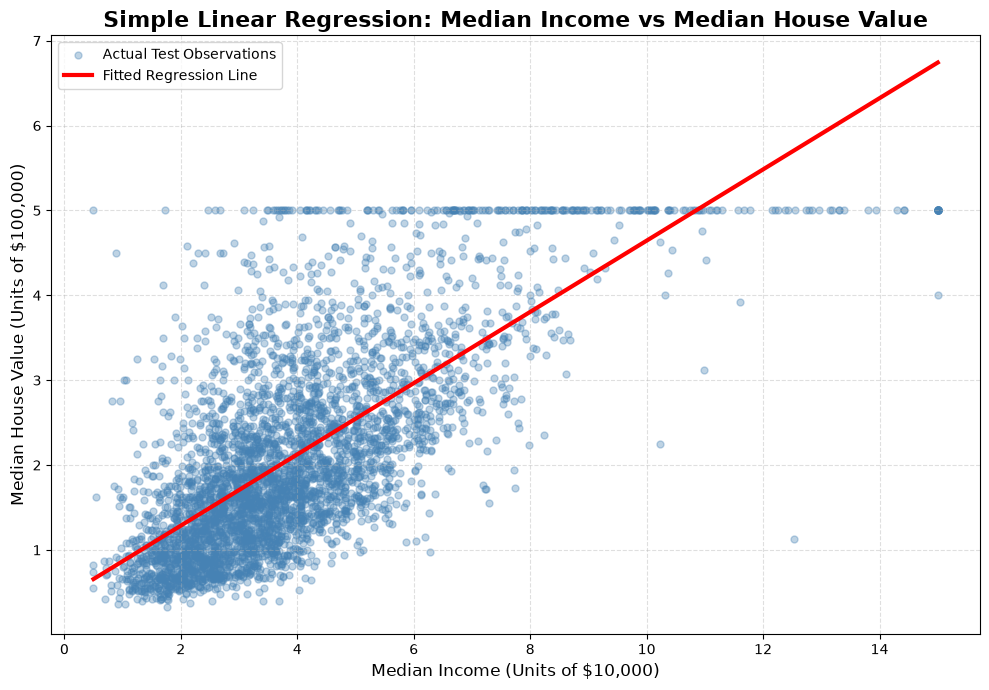

In [42]:
# Sort test observations by MedInc for a clean regression line
sorted_indices = np.argsort(X_test_simple["MedInc"].values)

X_test_sorted = X_test_simple["MedInc"].values[sorted_indices]
y_pred_sorted = y_pred_simple[sorted_indices]

plt.figure(figsize=(10, 7))

plt.scatter(
    X_test_simple["MedInc"],
    y_test_simple,
    alpha=0.35,
    s=25,
    color="steelblue",
    label="Actual Test Observations"
)

plt.plot(
    X_test_sorted,
    y_pred_sorted,
    color="red",
    linewidth=3,
    label="Fitted Regression Line"
)

plt.title(
    "Simple Linear Regression: Median Income vs Median House Value",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Median Income (Units of $10,000)", fontsize=12)
plt.ylabel("Median House Value (Units of $100,000)", fontsize=12)

plt.legend()
plt.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 5.9 Residual Analysis

Residuals represent the difference between actual and predicted values:

**Residual = Actual Value − Predicted Value**

A residual plot helps evaluate whether prediction errors are randomly distributed around zero. For an ideal linear model, residuals should generally show no strong systematic pattern. Visible structure, changing spread, or extreme residuals may indicate that the linear model does not fully capture the underlying relationship.

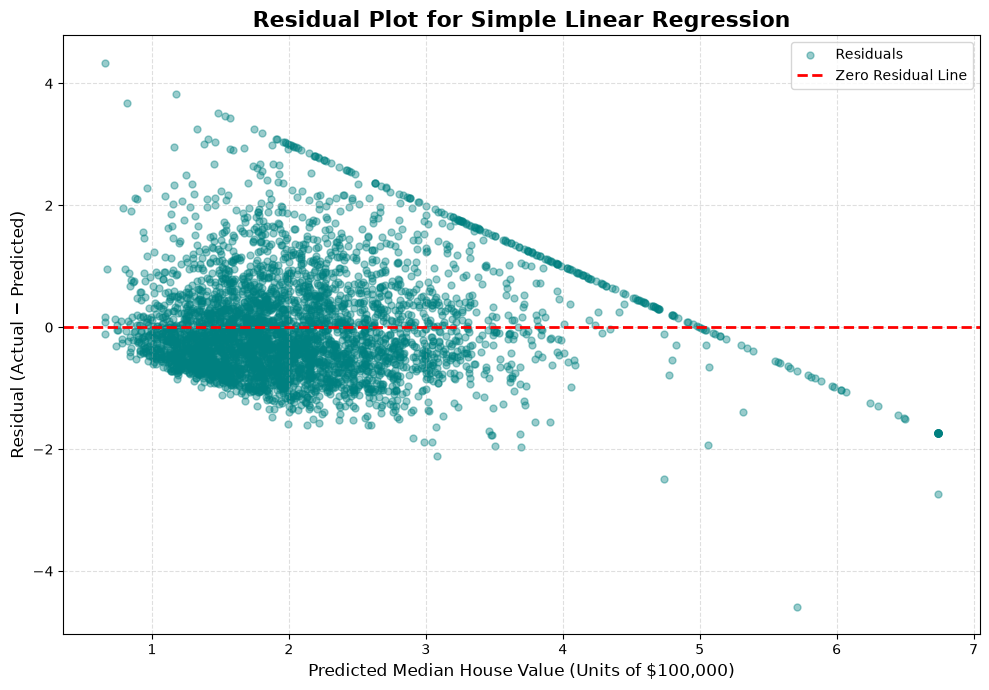

In [43]:
# Calculate residuals
simple_residuals = y_test_simple.values - y_pred_simple

plt.figure(figsize=(10, 7))

plt.scatter(
    y_pred_simple,
    simple_residuals,
    alpha=0.4,
    s=25,
    color="teal",
    label="Residuals"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Zero Residual Line"
)

plt.title(
    "Residual Plot for Simple Linear Regression",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel(
    "Predicted Median House Value (Units of $100,000)",
    fontsize=12
)
plt.ylabel(
    "Residual (Actual − Predicted)",
    fontsize=12
)

plt.legend()
plt.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Interpretation of Regression and Residual Plots

The regression-line plot confirms a clear positive relationship between median income and median house value. As `MedInc` increases, the model predicts higher house values. However, the observed values show considerable dispersion around the fitted line, indicating that median income alone cannot explain all variation in housing prices.

The horizontal concentration of observations at `MedHouseVal ≈ 5.0` is again visible and reflects the upper cap in the target variable. At higher income levels, the fitted regression line can predict values above this recorded target ceiling, demonstrating one limitation of applying an unconstrained linear model to a capped target variable.

The residual plot does not show a completely random, constant-width distribution around the zero-residual line. Instead, the spread and structure of the residuals vary across predicted values, suggesting that some assumptions of a simple linear relationship may not be fully satisfied.

A distinct diagonal boundary is also visible in the residual plot. This pattern is largely related to the upper cap in `MedHouseVal`: because many actual target values are fixed at approximately 5.0, their residuals follow the relationship `Residual ≈ 5.0 − Predicted Value`, producing a descending linear pattern.

Several relatively large positive and negative residuals are also present, indicating that the model substantially underpredicts or overpredicts some observations. This is consistent with the RMSE (0.8421) being higher than the MAE (0.6299), since RMSE is more sensitive to large prediction errors.

Overall, the residual analysis supports the conclusion that `MedInc` provides useful predictive information but that a single linear predictor cannot fully capture the complexity of California housing values. Additional socioeconomic, housing, and geographic features may help explain some of the remaining variation.

# Part 6 — Multiple Linear Regression

Multiple Linear Regression extends Simple Linear Regression by using several predictor variables simultaneously. This allows the model to capture information from different characteristics of the data rather than relying on median income alone.

## 6.1 Feature Selection

Five predictor variables are selected based on a combination of **correlation analysis, exploratory data analysis, and domain knowledge**:

- **`MedInc`** — Selected because it has the strongest individual correlation with `MedHouseVal` (r = 0.688), making it the most important starting predictor.
- **`AveRooms`** — Represents housing characteristics and has the second-highest positive correlation with the target (r = 0.152).
- **`HouseAge`** — Provides information about the age of housing stock and has a weak positive correlation with the target (r = 0.106).
- **`Latitude`** — Represents north-south geographic location and has a correlation of r = -0.144 with the target.
- **`Longitude`** — Although its individual correlation with the target is weak (r = -0.046), it is included together with latitude because the geographic EDA revealed clear spatial patterns in house values.

The feature selection is intentionally not based solely on the magnitude of individual Pearson correlations. In particular, latitude and longitude jointly encode geographic location and may provide predictive information that is not captured by their individual linear correlations.

The objective is to determine whether combining socioeconomic, housing, and geographic information improves predictive performance compared with the Simple Linear Regression model.

In [44]:
# Select five predictor features for Multiple Linear Regression
multiple_features = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "Latitude",
    "Longitude"
]

X_multiple = df[multiple_features]
y = df["MedHouseVal"]

print("Selected features:")
print(multiple_features)

print(f"\nPredictor shape: {X_multiple.shape}")
print(f"Target shape: {y.shape}")

Selected features:
['MedInc', 'HouseAge', 'AveRooms', 'Latitude', 'Longitude']

Predictor shape: (20640, 5)
Target shape: (20640,)


## 6.2 Train-Test Split

The data is divided into 80% training data and 20% testing data using the same `random_state=33` used for Simple Linear Regression.

Using the same test size and random state ensures that the Simple and Multiple Linear Regression models are evaluated on the same observations, making their performance comparison fair and consistent.

In [45]:
# Split the data using the same random state as Simple Linear Regression
X_train_multiple, X_test_multiple, y_train_multiple, y_test_multiple = train_test_split(
    X_multiple,
    y,
    test_size=0.20,
    random_state=33
)

print(f"Training observations: {X_train_multiple.shape[0]}")
print(f"Testing observations: {X_test_multiple.shape[0]}")

Training observations: 16512
Testing observations: 4128


## 6.3 Model Training

A Multiple Linear Regression model is trained using the five selected predictors. Each coefficient estimates the change in predicted `MedHouseVal` associated with a one-unit increase in that predictor while holding the other predictors constant.

In [46]:
# Initialize and train the Multiple Linear Regression model
multiple_lr = LinearRegression()

multiple_lr.fit(
    X_train_multiple,
    y_train_multiple
)

print(f"Intercept: {multiple_lr.intercept_:.4f}")

Intercept: -39.5133


In [47]:
# Create a table containing the coefficient for each feature
coefficient_table = pd.DataFrame({
    "Feature": multiple_features,
    "Coefficient": multiple_lr.coef_
})

# Add absolute coefficients for reference
coefficient_table["Absolute Coefficient"] = (
    coefficient_table["Coefficient"].abs()
)

coefficient_table.round(4)

,Feature,Coefficient,Absolute Coefficient
0,MedInc,0.3711,0.3711
1,HouseAge,0.0093,0.0093
2,AveRooms,0.0176,0.0176
3,Latitude,-0.4619,0.4619
4,Longitude,-0.4704,0.4704


## 6.4 Predictions and Model Evaluation

The trained Multiple Linear Regression model is used to predict median house values for the test set. Its performance is evaluated using the same R², MAE, and RMSE metrics used for Simple Linear Regression.

In [48]:
# Make predictions on the test set
y_pred_multiple = multiple_lr.predict(X_test_multiple)

# Calculate evaluation metrics
multiple_r2 = r2_score(
    y_test_multiple,
    y_pred_multiple
)

multiple_mae = mean_absolute_error(
    y_test_multiple,
    y_pred_multiple
)

multiple_rmse = np.sqrt(
    mean_squared_error(
        y_test_multiple,
        y_pred_multiple
    )
)

print("Multiple Linear Regression Performance")
print("-" * 42)
print(f"R² Score : {multiple_r2:.4f}")
print(f"MAE      : {multiple_mae:.4f}")
print(f"RMSE     : {multiple_rmse:.4f}")

print("\nApproximate Error in Dollar Terms")
print("-" * 42)
print(f"MAE  ≈ ${multiple_mae * 100000:,.2f}")
print(f"RMSE ≈ ${multiple_rmse * 100000:,.2f}")

Multiple Linear Regression Performance
------------------------------------------
R² Score : 0.6175
MAE      : 0.5432
RMSE     : 0.7212

Approximate Error in Dollar Terms
------------------------------------------
MAE  ≈ $54,315.91
RMSE ≈ $72,117.25


## 6.5 Interpretation of Multiple Linear Regression Coefficients

The fitted Multiple Linear Regression model produced an intercept of **-39.5133** and the following coefficients:

| Feature | Coefficient |
|---|---:|
| MedInc | 0.3711 |
| HouseAge | 0.0093 |
| AveRooms | 0.0176 |
| Latitude | -0.4619 |
| Longitude | -0.4704 |

Each coefficient represents the expected change in predicted `MedHouseVal` for a one-unit increase in that predictor, **while holding all other predictors constant**.

### Interpretation of Key Coefficients

1. **Median Income (`MedInc`) — Coefficient = 0.3711**

   Holding the other selected predictors constant, a one-unit increase in `MedInc` is associated with an increase of approximately **0.3711 units** in predicted `MedHouseVal`. Since one unit of `MedInc` represents $10,000 and one unit of `MedHouseVal` represents $100,000, this corresponds to an estimated increase of approximately **$37,110 in median house value** for each $10,000 increase in median income.

2. **Latitude — Coefficient = -0.4619**

   Holding the other predictors, including longitude, constant, a one-degree increase in latitude is associated with a decrease of approximately **0.4619 units** in predicted `MedHouseVal`, or about **$46,190**. This coefficient reflects a conditional geographic relationship within the linear model and should not be interpreted as latitude directly causing house prices to decrease.

3. **Longitude — Coefficient = -0.4704**

   Holding the other predictors, including latitude, constant, a one-degree increase in longitude is associated with a decrease of approximately **0.4704 units** in predicted `MedHouseVal`, equivalent to approximately **$47,040**. As with latitude, this coefficient captures part of the geographic pattern represented by the model rather than a direct causal effect.

`HouseAge` and `AveRooms` have smaller raw coefficients of **0.0093** and **0.0176**, respectively. However, raw coefficient magnitudes should not be used directly to rank feature importance because the predictors are measured on different scales. A feature-importance method will be used later for a more meaningful comparison.

## 6.6 Comparison with Simple Linear Regression

To determine whether adding multiple predictors improved performance, the Simple and Multiple Linear Regression models are compared using R², MAE, and RMSE.

For R², a higher value indicates better explanatory power. For MAE and RMSE, lower values indicate better predictive accuracy.

In [49]:
# Calculate improvements from Simple LR to Multiple LR
r2_improvement_points = multiple_r2 - simple_r2
r2_relative_improvement = (
    (multiple_r2 - simple_r2) / simple_r2
) * 100

mae_reduction = (
    (simple_mae - multiple_mae) / simple_mae
) * 100

rmse_reduction = (
    (simple_rmse - multiple_rmse) / simple_rmse
) * 100

# Create model comparison table
comparison_table = pd.DataFrame({
    "Metric": ["R² Score", "MAE", "RMSE"],
    "Simple LR": [
        simple_r2,
        simple_mae,
        simple_rmse
    ],
    "Multiple LR": [
        multiple_r2,
        multiple_mae,
        multiple_rmse
    ],
    "Improvement": [
        f"+{r2_improvement_points:.4f} points ({r2_relative_improvement:.2f}% relative)",
        f"{mae_reduction:.2f}% lower",
        f"{rmse_reduction:.2f}% lower"
    ]
})

comparison_table.round({
    "Simple LR":4,
    "Multiple LR":4
})

,Metric,Simple LR,Multiple LR,Improvement
0,R² Score,0.4980,0.6175,+0.1195 points (24.00% relative)
1,MAE,0.6271,0.5432,13.39% lower
2,RMSE,0.8262,0.7212,12.71% lower


### Interpretation of Model Comparison

The Multiple Linear Regression model outperformed the Simple Linear Regression model across all evaluation metrics.

- The **R² Score increased from 0.4980 to 0.6175**, representing an improvement of **0.1195 points (11.95 percentage points of explained variance)**. Relative to the Simple Linear Regression model, this corresponds to an improvement of approximately **24.00%**.

- The **Mean Absolute Error (MAE)** decreased from **0.6271** to **0.5432**, reducing the average prediction error from approximately **$62,710** to **$54,320**, an improvement of **13.38%**.

- The **Root Mean Squared Error (RMSE)** decreased from **0.8262** to **0.7212**, reducing the prediction error from approximately **$82,620** to **$72,120**, corresponding to a **12.71%** improvement.

These results demonstrate that incorporating additional housing and geographic information meaningfully improves predictive performance. Although `MedInc` remains the strongest individual predictor, variables such as `HouseAge`, `AveRooms`, `Latitude`, and `Longitude` provide complementary information that allows the model to explain a substantially larger proportion of the variation in median house values.

Despite this improvement, approximately **38.25%** of the variation in house values remains unexplained. This suggests that housing prices are influenced by additional nonlinear relationships, feature interactions, omitted variables, and the upper cap present in the target variable. More flexible machine learning models may therefore achieve higher predictive accuracy.

## 6.7 Residual Analysis for Multiple Linear Regression

The residual plot is used to evaluate whether the Multiple Linear Regression model has reduced prediction errors compared with the Simple Linear Regression model.

Ideally, residuals should be randomly distributed around zero without obvious systematic patterns.

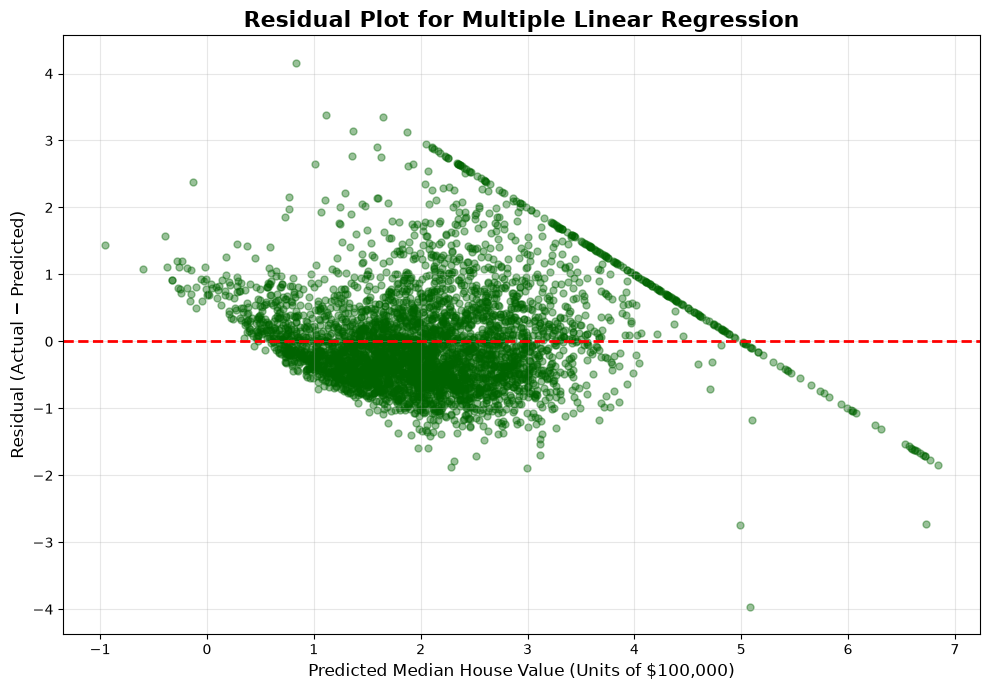

In [50]:
# Residuals for Multiple Linear Regression
multiple_residuals = y_test_multiple.values - y_pred_multiple

plt.figure(figsize=(10,7))

plt.scatter(
    y_pred_multiple,
    multiple_residuals,
    alpha=0.4,
    color="darkgreen",
    s=25
)

plt.axhline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Residual Plot for Multiple Linear Regression",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Median House Value (Units of $100,000)",
    fontsize=12
)

plt.ylabel(
    "Residual (Actual − Predicted)",
    fontsize=12
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Part 7 — Visualization Portfolio

This section consolidates the required visualization portfolio. Rather than duplicating charts, each item below references the specific section where it was already created, confirming all required visualization types are present with proper titles, labeled axes, and legends.

| Required Visualization | Location in Notebook |
|---|---|
| **Histogram** — target variable + other features | Section 3.2.1 (all numerical features) and Section 3.2.2 (target variable, `MedHouseVal`, in detail) |
| **Box Plot** — outlier detection, 3+ features | Section 3.2.4 — Box plots for `MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup` |
| **Scatter Plot** — features vs. target, with trend line | Section 3.2.9 (predictor relationships) and Section 5.8 (Simple Linear Regression line overlaid on actual data) |
| **Correlation Heatmap** — full matrix, color-coded | Section 3.2.7 |
| **Regression Line Plot** — Simple LR prediction line | Section 5.8 |
| **Residual Plot** — residuals vs. predicted values | Section 5.9 (Simple Linear Regression) and Section 6.7 (Multiple Linear Regression) |

**Additional visualizations:**
- Geographic scatter plot of house values by Latitude/Longitude (Section 3.2.10)
- Pair plot of key features (Section 3.2.11)

# Part 8 — Conclusion & Reflection

This assignment applied the full statistical and regression analysis workflow to the California Housing dataset — from data inspection and cleaning through exploratory analysis, Simple Linear Regression, and Multiple Linear Regression.

**What I learned:** The clearest lesson was that a feature's individual Pearson correlation with the target does not fully determine its predictive value. `Latitude` and `Longitude` each showed weak individual correlations with `MedHouseVal` (r = -0.144 and r = -0.046), yet together they produced the two largest coefficients in the Multiple Linear Regression model (-0.462 and -0.470), and adding them alongside `HouseAge` and `AveRooms` improved R² from 0.4980 to 0.6175, a 24.0% relative improvement. This reinforced why exploratory visualization mattered as much as the correlation table: the geographic scatter plot revealed spatial clustering of high-value coastal areas that neither coordinate's individual correlation coefficient could show on its own.

**Most surprising finding:** The near-identical magnitude of the Latitude and Longitude coefficients (-0.462 and -0.470) turned out to be a meaningful signal in itself, a symptom of the strong correlation between the two variables (r = -0.92), meaning the model cannot cleanly separate how much of the location effect belongs to each coordinate individually, even though their *combined* contribution is clearly substantial and real.

**Challenges faced:** The extreme outliers in `AveRooms`, `AveBedrms`, and `AveOccup` (some block groups reporting over 100 average rooms or 1,000+ occupants) initially looked like data errors. After confirming all values were logically valid (no negatives, no impossible ranges), I decided to keep them, treating them as genuine, if unusual, small-population block groups rather than removing data the model could still learn from. I also had to work around the capped target variable ($500,000 ceiling, affecting 4.68% of rows), which appeared as a diagonal artifact in the residual plots of both regression models and had to be explained as a data-collection limitation rather than a modeling error.

**Real business relevance:** This workflow mirrors what a real estate analytics or lending team would use to estimate property values, flag mispriced listings, or assess regional pricing risk. Starting with an interpretable linear model, where every coefficient has a clear, explainable meaning, reflects how analysts typically build stakeholder trust before introducing more complex modeling approaches.

**What I would do differently with more time:** I would engineer additional location-based features, such as distance to the nearest coastline or major city, rather than relying on raw Latitude and Longitude, whose strong mutual correlation limits how confidently their individual coefficients can be interpreted. I would also test log-transforming the heavily right-skewed features (`AveRooms`, `AveOccup`, `Population`) before regression. As an extension beyond the core requirements, the bonus section that follows explores whether a non-linear model such as Random Forest can capture patterns that these linear models cannot.

**Connection to machine learning:** This project reflects the standard supervised learning workflow — cleaning, EDA, feature selection, train/test splitting, baseline modeling, and evaluation — that underlies most real-world predictive systems. Understanding *why* a feature like `AveOccup` shows almost no linear correlation yet might still matter, and why correlated features like Latitude/Longitude can jointly add value despite ambiguous individual coefficients, is foundational to understanding both linear models and the more complex models that build on the same underlying data.

**Remaining questions:** I'm curious whether engineered geographic features (e.g., distance-to-coast) would resolve the coefficient instability between Latitude and Longitude, and how much further predictive performance could improve with a non-linear model.

# Stretch Goal 1 — Random Forest Regression

Linear Regression assumes that the relationship between the predictor variables and the target variable is linear.

However, real-world housing prices are influenced by complex nonlinear relationships and interactions between variables. Random Forest Regression is an ensemble machine learning algorithm that combines multiple decision trees to capture these nonlinear patterns.

The objective of this section is to compare the predictive performance of Random Forest Regression with both Simple Linear Regression and Multiple Linear Regression using identical training and testing datasets.

In [51]:
from sklearn.ensemble import RandomForestRegressor

In [52]:
# Initialize a baseline Random Forest Regressor
random_forest = RandomForestRegressor(
    n_estimators=300,
    random_state=33,
    n_jobs=-1
)

# Train the model
random_forest.fit(
    X_train_multiple,
    y_train_multiple
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",33
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [53]:
# Predict on the test set
y_pred_rf = random_forest.predict(X_test_multiple)

In [54]:
# Evaluate the Random Forest model
rf_r2 = r2_score(y_test_multiple, y_pred_rf)
rf_mae = mean_absolute_error(y_test_multiple, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test_multiple, y_pred_rf))

print("Random Forest Performance")
print("-" * 40)
print(f"R² Score : {rf_r2:.4f}")
print(f"MAE      : {rf_mae:.4f}")
print(f"RMSE     : {rf_rmse:.4f}")

Random Forest Performance
----------------------------------------
R² Score : 0.8341
MAE      : 0.3125
RMSE     : 0.4749


In [55]:
# Final comparison of all models
final_model_comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Random Forest Regression"
    ],
    "R² Score": [
        simple_r2,
        multiple_r2,
        rf_r2
    ],
    "MAE": [
        simple_mae,
        multiple_mae,
        rf_mae
    ],
    "RMSE": [
        simple_rmse,
        multiple_rmse,
        rf_rmse
    ]
})

final_model_comparison.round(4)

,Model,R² Score,MAE,RMSE
0,Simple Linear Regression,0.4980,0.6271,0.8262
1,Multiple Linear Regression,0.6175,0.5432,0.7212
2,Random Forest Regression,0.8341,0.3125,0.4749


## Comparison of Regression Models

The performance of the three regression models is summarized below.

| Model | R² Score | MAE | RMSE |
|-------|----------:|----------:|----------:|
| Simple Linear Regression | 0.4980 | 0.6271 | 0.8262 |
| Multiple Linear Regression | 0.6175 | 0.5432 | 0.7212 |
| Random Forest Regression | 0.8341 | 0.3125 | 0.4749 |

### Interpretation

Among the three models, **Random Forest Regression achieved the best predictive performance**.

Compared with Multiple Linear Regression:

- The **R² Score increased from 0.6175 to 0.8341**, indicating that the Random Forest model explains substantially more variation in median house values.
- The **MAE decreased from 0.5432 to 0.3125**, reducing the average prediction error by approximately **42.47%**.
- The **RMSE decreased from 0.7212 to 0.4749**, reducing large prediction errors by approximately **34.15%**.

The improved performance is expected because Random Forest is capable of learning nonlinear relationships and complex interactions between predictor variables that cannot be captured by ordinary linear regression.

Overall, Random Forest Regression is the most suitable model among the three evaluated models for predicting California housing prices in this project.

In [56]:
from sklearn.model_selection import RandomizedSearchCV

In [57]:
# Hyperparameter search space
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

In [58]:
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=33),
    param_distributions=param_dist,
    n_iter=20,
    scoring="r2",
    cv=5,
    random_state=33,
    n_jobs=-1
)

In [59]:
random_search.fit(
    X_train_multiple,
    y_train_multiple
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=33)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",33
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Al

In [60]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation R²:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}

Best Cross-Validation R²:
0.8054590245228418


In [61]:
best_rf = random_search.best_estimator_

y_pred_best = best_rf.predict(X_test_multiple)

In [62]:
best_r2 = r2_score(y_test_multiple, y_pred_best)
best_mae = mean_absolute_error(y_test_multiple, y_pred_best)
best_rmse = np.sqrt(mean_squared_error(y_test_multiple, y_pred_best))

print("Tuned Random Forest")
print("-" * 30)
print(f"R² Score : {best_r2:.4f}")
print(f"MAE      : {best_mae:.4f}")
print(f"RMSE     : {best_rmse:.4f}")

Tuned Random Forest
------------------------------
R² Score : 0.8337
MAE      : 0.3190
RMSE     : 0.4755


### Hyperparameter Tuning Summary

Hyperparameter tuning was performed using RandomizedSearchCV with 5-fold cross-validation.

Although the tuned model achieved a strong cross-validation performance, its test-set performance was marginally lower than the baseline Random Forest model.

Therefore, the baseline Random Forest model was retained as the final model for the remainder of the analysis because it achieved slightly better generalization on unseen data.

# Stretch Goal 2 — Feature Importance Analysis

Feature importance helps identify which predictor variables contribute the most to the Random Forest model's predictions.

Two different approaches are used:

1. Random Forest's built-in feature importance (based on impurity reduction).
2. Permutation Importance (based on the decrease in model performance when a feature is randomly shuffled).

Using both methods provides a more comprehensive understanding of the influence of each feature.

In [63]:
# Create DataFrame of feature importances
feature_importance = pd.DataFrame({
    "Feature": X_train_multiple.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.round(4)

,Feature,Importance
0,MedInc,0.5277
4,Longitude,0.1605
3,Latitude,0.1523
2,AveRooms,0.0832
1,HouseAge,0.0763


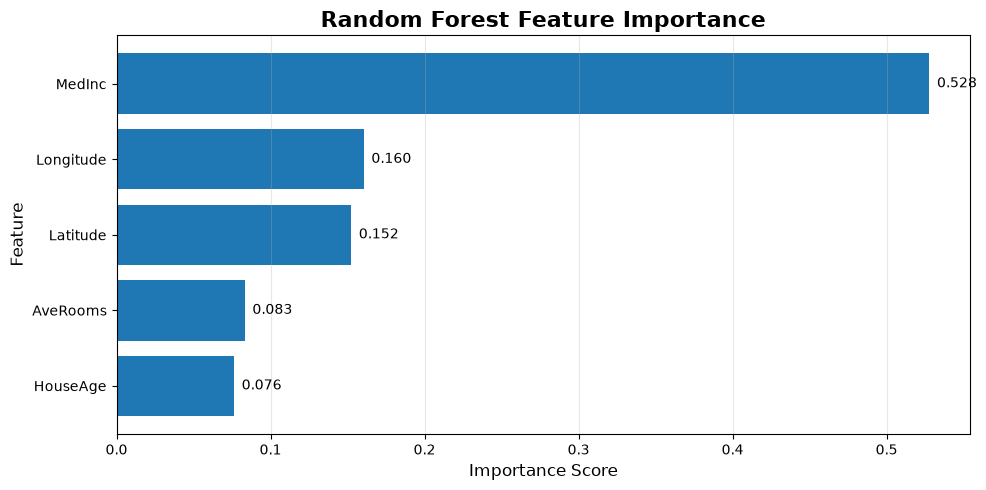

In [64]:
plt.figure(figsize=(10, 5))

bars = plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Random Forest Feature Importance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)

plt.grid(axis="x", alpha=0.3)

# Display importance values
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [65]:
from sklearn.inspection import permutation_importance

In [66]:
perm_importance = permutation_importance(
    random_forest,
    X_test_multiple,
    y_test_multiple,
    n_repeats=20,
    random_state=33,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": X_test_multiple.columns,
    "Importance": perm_importance.importances_mean
})

perm_df = perm_df.sort_values(
    by="Importance",
    ascending=False
)

perm_df.round(4)

,Feature,Importance
3,Latitude,0.8692
4,Longitude,0.8423
0,MedInc,0.6465
2,AveRooms,0.0785
1,HouseAge,0.0640


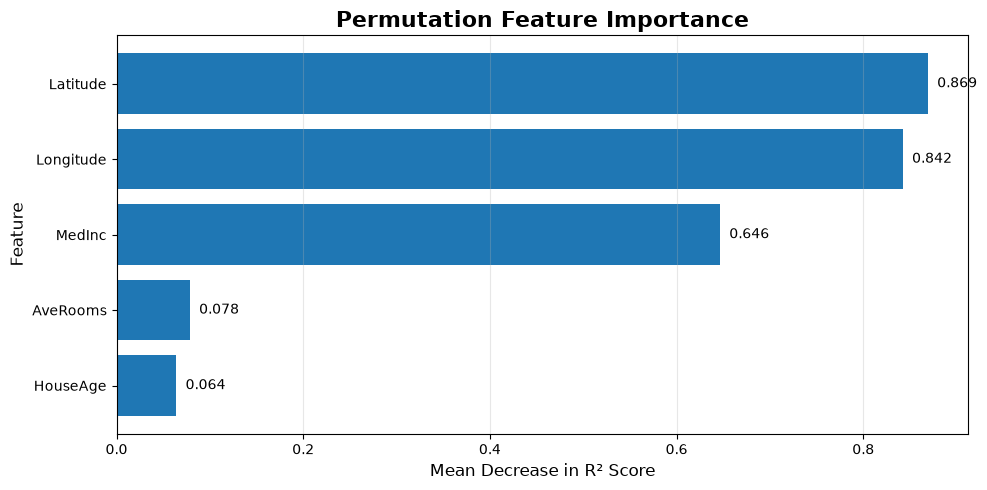

In [67]:
plt.figure(figsize=(10, 5))

bars = plt.barh(
    perm_df["Feature"],
    perm_df["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Permutation Feature Importance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Mean Decrease in R² Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)

plt.grid(axis="x", alpha=0.3)

# Display importance values
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Interpretation of Feature Importance

Two complementary methods were used to evaluate feature importance in the Random Forest model: **impurity-based feature importance** and **permutation importance**.

### Random Forest Feature Importance

The impurity-based feature importance indicates that **Median Income (`MedInc`)** is the most influential predictor, followed by **Longitude**, **Latitude**, **Average Rooms**, and **House Age**. This method measures how much each feature contributes to reducing impurity during the construction of decision trees.

### Permutation Importance

Permutation importance produces a different ranking. It identifies **Latitude** and **Longitude** as the most influential predictors, followed by **Median Income**. This method evaluates feature importance by measuring the decrease in model performance after randomly shuffling the values of each feature.

### Discussion

The difference in rankings is expected because the two methods measure different aspects of feature importance.

- **Impurity-based importance** evaluates how useful a feature is for splitting nodes while building the Random Forest.
- **Permutation importance** evaluates how much the trained model depends on a feature for making accurate predictions.

Although the rankings differ slightly, both methods consistently identify **Median Income, Latitude, and Longitude** as the three most influential predictors. This indicates that both **economic factors** (represented by median income) and **geographic location** (represented by latitude and longitude) play a dominant role in predicting California housing prices.

The agreement between these two independent feature importance methods increases confidence in the model's interpretation and supports the conclusions drawn from the exploratory data analysis.

In [68]:
comparison_importance = pd.DataFrame({
    "Random Forest Importance": feature_importance["Feature"].values,
    "Permutation Importance": perm_df["Feature"].values
})

comparison_importance.index = comparison_importance.index + 1
comparison_importance.index.name = "Rank"

comparison_importance

,Random Forest Importance,Permutation Importance
Rank,,
1,MedInc,Latitude
2,Longitude,Longitude
3,Latitude,MedInc
4,AveRooms,AveRooms
5,HouseAge,HouseAge


In [69]:
import plotly.express as px
import plotly.graph_objects as go

# Stretch Goal 3 — Interactive Plotly Visualizations

Plotly provides interactive visualizations that allow users to zoom, pan, hover over data points, and export figures. These capabilities make exploratory data analysis more informative than static visualizations and are well suited for deployment in interactive dashboards.

In [70]:
fig = px.histogram(
    df,
    x="MedHouseVal",
    nbins=40,
    title="Interactive Distribution of Median House Value"
)

fig.update_layout(
    xaxis_title="Median House Value (Units of $100,000)",
    yaxis_title="Frequency"
)

fig.show()

In [71]:
corr_matrix = df.corr(numeric_only=True)

fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    aspect="auto",
    title="Interactive Correlation Heatmap"
)

fig.show()

In [72]:
fig = px.scatter(
    df,
    x="MedInc",
    y="MedHouseVal",
    trendline="ols",
    opacity=0.5,
    title="Median Income vs Median House Value"
)

fig.update_layout(
    xaxis_title="Median Income",
    yaxis_title="Median House Value"
)

fig.show()

In [73]:
import joblib

# Save the trained Random Forest model and its feature list
# (used by app.py, the Streamlit dashboard built for Stretch Goal 4)
joblib.dump(random_forest, "rf_model.pkl")
joblib.dump(multiple_features, "model_features.pkl")

print("Model saved as rf_model.pkl")
print("Feature list saved as model_features.pkl")
print(f"Features: {multiple_features}")

Model saved as rf_model.pkl
Feature list saved as model_features.pkl
Features: ['MedInc', 'HouseAge', 'AveRooms', 'Latitude', 'Longitude']


In [74]:
# Save results tables for the Streamlit dashboard
final_model_comparison.to_csv("model_comparison.csv", index=False)
feature_importance.to_csv("feature_importance.csv", index=False)

print("Saved model_comparison.csv and feature_importance.csv for the dashboard")

Saved model_comparison.csv and feature_importance.csv for the dashboard


In [75]:
import joblib

joblib.dump(random_forest, "model.pkl", compress=3)
print("Model saved as model.pkl (compressed)")

Model saved as model.pkl (compressed)


In [76]:
# Lightweight model for deployment — used only for the Streamlit dashboard.
# The official Random Forest results (reported above) are untouched.
deploy_model = RandomForestRegressor(
    n_estimators=100, max_depth=15, min_samples_leaf=5, random_state=33
)
deploy_model.fit(X_train_multiple, y_train_multiple)

joblib.dump(deploy_model, "model.pkl", compress=3)

import os
size_mb = os.path.getsize("model.pkl") / 1e6
print(f"Deployment model saved. Size: {size_mb:.2f} MB")

Deployment model saved. Size: 6.93 MB


# Stretch Goal 4 — Interactive Dashboard with Streamlit

An interactive multi-page Streamlit dashboard was built as a separate application (`app.py`, included in this submission) rather than inside this notebook, since Streamlit apps run as standalone Python scripts outside the Jupyter/IPython environment.

**Dashboard pages:**
- **Home** — project overview, dataset summary, and tools used
- **Prediction** — input fields for `MedInc`, `HouseAge`, `AveRooms`, `Latitude`, and `Longitude`, producing a live predicted median house value (in dollars) from the trained Random Forest model
- **Exploratory Data Analysis** — interactive Plotly visualizations: house price distribution, median income vs. house price (with OLS trendline), and a correlation heatmap
- **Feature Importance** — bar chart of Random Forest feature importances, loaded directly from `feature_importance.csv` (generated by this notebook)
- **Model Performance** — comparison table and bar chart of R², MAE, and RMSE across Simple LR, Multiple LR, and Random Forest, loaded directly from `model_comparison.csv` (generated by this notebook)

**To run the dashboard locally:**
- pip install -r requirements.txt
- streamlit run app.py

The app loads `model.pkl` (a depth-limited Random Forest trained for lightweight deployment — see note below), `data/california_housing.csv`, `model_comparison.csv`, and `feature_importance.csv`, all produced by this notebook.

**Note on the deployed model:** For deployment, a separate depth-capped Random Forest (`max_depth=15`, `min_samples_leaf=5`) was trained and saved as `model.pkl`, since the full-depth model used for the results reported in this notebook exceeded GitHub's 100MB file size limit when serialized. The notebook's official reported metrics (R² = 0.8341) come from the full, untouched `random_forest` model; the deployed dashboard uses this lighter version for predictions, with a small, expected trade-off in accuracy.

# Stretch Goal 5 — Deployment

**Live app:** https://vcti-california-housing-dashboard-npgtu2bsf4pducwcepy8ks.streamlit.app/

The dashboard above was deployed to **Streamlit Community Cloud** for public access without requiring a local Python installation. The source code is hosted on GitHub and deploys automatically on every push to the main branch.